##### **A.1 Import Data and Overview**

In [1]:
import pandas as pd

In [2]:
# import data
df = pd.read_parquet('1B.parquet')
df.head()

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
0,1933,Maruti,2013,4500.00,41800,South,Florida,Orlando,Petrol,Individual,Manual,First_Owner,18.6,1197,85.8,114Nm@ 4000rpm,5,Y
1,4901,Ford,2004,4000.00,93415,East,Massachusetts,Abington,Diesel,Dealer,Manual,First_Owner,13.1,2499,141.0,330Nm@ 1800rpm,7,N
2,2802,Honda,2017,8199.99,12000,South,Arkansas,Benton,Petrol,Individual,Manual,First_Owner,17.5,1199,88.7,110Nm@ 4800rpm,5,N
3,7949,Maruti,2016,6750.00,108000,East,New York,East Massapequa,Diesel,Dealer,Manual,First_Owner,23.65,1248,88.5,200Nm@ 1750rpm,5,N
4,966,Maruti,2019,6750.00,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.1,115Nm@ 4000rpm,5,Y


In [3]:
# lets check the data info (data types, non-null values, etc.)
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales_ID           2000 non-null   int64  
 1   name               2000 non-null   str    
 2   year               2000 non-null   int64  
 3   selling_price      1998 non-null   float64
 4   km_driven          2000 non-null   int64  
 5   Region             2000 non-null   str    
 6   State or Province  2000 non-null   str    
 7   City               2000 non-null   str    
 8   fuel               2000 non-null   str    
 9   seller_type        2000 non-null   str    
 10  transmission       2000 non-null   str    
 11  owner              2000 non-null   str    
 12  mileage            2000 non-null   str    
 13  engine             2000 non-null   int64  
 14  max_power          2000 non-null   float64
 15  torque             2000 non-null   str    
 16  seats              2000 non-null   

Saya menemukan beberapa Data Type yang tidak sesuai dengan kolomnya (fitur torque), serta ada 2 missing value. Mari kita recheck kembali.

In [4]:
#lets check for the missing values first
df.isnull().sum()

Sales_ID             0
name                 0
year                 0
selling_price        2
km_driven            0
Region               0
State or Province    0
City                 0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage              0
engine               0
max_power            0
torque               0
seats                0
sold                 0
dtype: int64

Ternyata benar, terdapat 2 missing value pada kolom target kita yaitu kolom selling price. Jika terdapat missing value pada selling price, maka kita tidak dapat melakukan imputasi.

In [5]:
# check row yang memiliki missing value
df[df['selling_price'].isnull()]

,Sales_ID,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
702,7365,Maruti,2015,NaN,59292,South,Arkansas,Texarkana,Diesel,Dealer,Manual,First_Owner,28.4,1248,74.00,190Nm@ 2000rpm,5,N
1914,3884,Hyundai,2014,NaN,110000,South,Florida,Davie,Diesel,Individual,Manual,First_Owner,22.54,1396,88.73,219.7Nm@ 1500-2750rpm,5,N


In [6]:
df = df.dropna(subset=['selling_price'])

In [7]:
# cek kembali hasilnya apakah sudah benar
df.isnull().sum()

Sales_ID             0
name                 0
year                 0
selling_price        0
km_driven            0
Region               0
State or Province    0
City                 0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage              0
engine               0
max_power            0
torque               0
seats                0
sold                 0
dtype: int64

Setelah mengatasi data yang memiliki missing value, sekarang mari kita periksa data yang memiliki duplikat

In [8]:
# check duplicates
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


Saya tidak menemukan ada duplicate data di dalam dataset.

#### **A.2 Exploring Columns**

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.edgecolor": "#EEEEEE",
        "axes.facecolor": "#F9FAFB",
        "grid.color": "#E5E7EB",
        "axes.labelcolor": "#374151",
        "xtick.color": "#6B7280",
        "ytick.color": "#6B7280",
        "axes.titlesize": 14,
        "axes.titleweight": "semibold",
        "axes.titlecolor": "#374151",
    }
)

sns.set_palette(
    sns.color_palette(["#0f766e", "#14b8a6", "#2dd4bf", "#5eead4", "#99f6e4"])
)

In [10]:
df.dtypes

Sales_ID               int64
name                     str
year                   int64
selling_price        float64
km_driven              int64
Region                   str
State or Province        str
City                     str
fuel                     str
seller_type              str
transmission             str
owner                    str
mileage                  str
engine                 int64
max_power            float64
torque                   str
seats                  int64
sold                     str
dtype: object

In [11]:
# check unique values in categorical columns
df.select_dtypes(include=['object']).nunique()

C:\Users\Tuf Gaming\AppData\Local\Temp\ipykernel_26072\2890648636.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).nunique()


name                  27
Region                 5
State or Province     49
City                 935
fuel                   4
seller_type            3
transmission           3
owner                  5
mileage              305
torque               292
sold                   2
dtype: int64

##### **A.2.1 Sales_ID**

In [12]:
df['Sales_ID'].unique()

array([1933, 4901, 2802, ...,  742,  169, 5407], shape=(1998,))

Karena dilihat bahwa sales_ID merupakan uninformative feature, maka kita akan menghapusnya saja

In [13]:
df = df.drop(columns=['Sales_ID'])

##### **A.2.2 Name**

In [14]:
df['name'].unique()

<ArrowStringArray>
[    'Maruti',       'Ford',      'Honda',  'Chevrolet',    'Renault',
    'Hyundai', 'Volkswagen',   'Mahindra',     'Datsun',      'Skoda',
       'Tata',     'Toyota',   'Mercedes',      'Volvo',        'BMW',
       'Jeep',       'Audi',     'Jaguar', 'Mitsubishi',       'Fiat',
       'Land',     'Nissan',      'Force',      'Lexus',      'Isuzu',
     'Daewoo',         'MG']
Length: 27, dtype: str

In [15]:
df['name'].value_counts().head(20)

name
Maruti        578
Hyundai       360
Mahindra      184
Tata          184
Toyota        122
Ford          115
Honda         114
Renault        54
Chevrolet      49
Volkswagen     45
Skoda          35
BMW            27
Volvo          22
Datsun         21
Nissan         19
Jaguar         16
Mercedes       12
Lexus          10
Fiat            8
Jeep            7
Name: count, dtype: int64

##### **A.2.3 Year**

In [16]:
df['year'].describe()

count    1998.000000
mean     2014.544044
std        22.605272
min      1999.000000
25%      2012.000000
50%      2015.000000
75%      2017.000000
max      3011.000000
Name: year, dtype: float64

In [17]:
df['year'].value_counts()

year
2017    245
2015    211
2016    210
2013    203
2018    189
2014    160
2019    157
2012    150
2011    138
2010     86
2009     60
2008     54
2007     38
2006     31
2005     19
2020     16
2004     13
2003      8
2000      4
1999      3
2002      2
3011      1
Name: count, dtype: int64

##### **A.2.4 Selling Price**

In [18]:
df['selling_price'].describe()

count      1998.000000
mean       6500.861947
std        8322.011983
min         350.000000
25%        2750.000000
50%        4500.000000
75%        6750.000000
max      100000.000000
Name: selling_price, dtype: float64

##### **A.2.5 Region**

In [19]:
df['Region'].unique()

<ArrowStringArray>
['South', 'East', 'Central', 'West', 'N/A']
Length: 5, dtype: str

In [20]:
df['Region'].value_counts()

Region
Central    605
West       507
East       483
South      401
N/A          2
Name: count, dtype: int64

In [21]:
df[df['Region']=='N/A']

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
728,Maruti,2013,6000.0,60000,N/A,Illinois,Chicago,Diesel,Individual,Manual,First_Owner,20.77,1248,88.8,200Nm@ 1750rpm,7,Y
1468,Mahindra,2013,3000.0,120000,N/A,Illinois,Chicago,Diesel,Individual,Manual,Second_Owner,17.21,1493,100.0,240Nm@ 1600-2800rpm,7,Y


Pada kolom Region terdapat abnormal values yakni N/A yang tidak terdeteksi sebagai NULL value.

Tetapi karena jumlahnya hanya ada 2 dan kita bisa melakukan inputation berdasarkan informasi dari kolom State dan city.

In [22]:
# check data city = CHicago
df[df['City']=='Chicago'].head(3)

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
4,Maruti,2019,6750.0,5000,Central,Illinois,Chicago,Petrol,Individual,Automatic,First_Owner,21.4,1197,83.10,115Nm@ 4000rpm,5,Y
77,Maruti,2017,5500.0,50000,Central,Illinois,Chicago,Petrol,Individual,Manual,First_Owner,20.85,1197,83.14,115Nm@ 4000rpm,5,Y
117,Ford,2011,3000.0,110000,Central,Illinois,Chicago,Diesel,Individual,Manual,Third_Owner,17.8,1399,68.00,"16.3@ 2,000(kgm@ rpm)",5,Y


Berdasarkan informasi di atas, bisa kita asusmsikan bahwa mobil yang dijual di kota Chicago provinsi Illinois, pastii ada di region Central.

In [23]:
# handle
df.loc[df['Region']=='N/A', 'Region'] = 'Central'

In [24]:
df['Region'].value_counts()

Region
Central    607
West       507
East       483
South      401
Name: count, dtype: int64

In [25]:
# Check kembali apakah sudah benar
df[df['Region']=='N/A']

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold


##### **A.2.6 State or Province**

In [26]:
df['State or Province'].unique()

<ArrowStringArray>
[             'Florida',        'Massachusetts',             'Arkansas',
             'New York',             'Illinois',           'Washington',
              'Alabama',               'Nevada',            'Minnesota',
           'California',             'Colorado',               'Oregon',
             'Michigan',                 'Ohio',             'Oklahoma',
              'Indiana',                 'Iowa',                'Texas',
              'Georgia',                'Maine',             'Maryland',
           'New Jersey',              'Arizona',               'Kansas',
         'Pennsylvania',              'Montana',             'Virginia',
            'Tennessee',        'New Hampshire',          'Mississippi',
       'North Carolina',        'West Virginia',             'Nebraska',
                 'Utah', 'District of Columbia',           'New Mexico',
         'Rhode Island',         'South Dakota',             'Kentucky',
            'Wisconsin',       '

##### **A.2.7 Fuel**

In [27]:
df['fuel'].unique()

<ArrowStringArray>
['Petrol', 'Diesel', 'LPG', 'CNG']
Length: 4, dtype: str

##### **A.2.8 Seller Type**

In [28]:
df['seller_type'].unique()

<ArrowStringArray>
['Individual', 'Dealer', 'Trustmark_Dealer']
Length: 3, dtype: str

In [29]:
df['seller_type'].value_counts()

seller_type
Individual          1631
Dealer               298
Trustmark_Dealer      69
Name: count, dtype: int64

##### **A.2.9 Tranmission**

In [30]:
df['transmission'].unique()

<ArrowStringArray>
['Manual', 'Automatic', '']
Length: 3, dtype: str

In [31]:
df['transmission'].value_counts()

transmission
Manual       1741
Automatic     255
                2
Name: count, dtype: int64

Pada fitur Transmission pun mengalami hal yang sama terdapat empty value yang tidak terdeteksi isnull function.

In [32]:
df[df['transmission']=='']

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
433,Maruti,2012,1850.0,60000,South,Arkansas,Bentonville,Petrol,Individual,,Second_Owner,19.7,796,46.3,62Nm@ 3000rpm,5,N
1138,Maruti,2019,3950.0,5000,East,New Jersey,Phillipsburg,Petrol,Individual,,First_Owner,15.37,1196,73.0,101Nm@ 3000rpm,7,Y


In [33]:
# cari data yang memiliki value yang hampir mirip
df[(df['name']== 'Maruti')  & (df['Region']== 'South') & (df['State or Province']== 'Arkansas')]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
164,Maruti,2017,6500.0,78000,South,Arkansas,Benton,Diesel,Individual,Manual,Third_Owner,28.09,1248,88.50,200Nm@ 1750rpm,5,N
433,Maruti,2012,1850.0,60000,South,Arkansas,Bentonville,Petrol,Individual,,Second_Owner,19.7,796,46.30,62Nm@ 3000rpm,5,N
492,Maruti,2005,1100.0,50800,South,Arkansas,Conway,Petrol,Dealer,Manual,Second_Owner,19.7,796,46.30,62Nm@ 3000rpm,5,N
915,Maruti,2019,6500.0,5621,South,Arkansas,Paragould,Petrol,Trustmark_Dealer,Automatic,First_Owner,22.0,1197,81.80,113Nm@ 4200rpm,5,Y
986,Maruti,2017,7000.0,80000,South,Arkansas,Searcy,Diesel,Individual,Automatic,First_Owner,28.4,1248,74.02,190Nm@ 2000rpm,5,N
1968,Maruti,2018,5500.0,5000,South,Arkansas,Fort Smith,Petrol,Individual,Manual,First_Owner,22.0,1197,81.80,113Nm@ 4200rpm,5,Y


In [34]:
df[(df['name']== 'Maruti') & (df['torque']== '101Nm@ 3000rpm')]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
107,Maruti,2011,1600.00,100000,South,Georgia,Dalton,Petrol,Individual,Manual,Second_Owner,15.37,1196,73.0,101Nm@ 3000rpm,7,N
181,Maruti,2010,1500.00,170000,Central,Kansas,Overland Park,Petrol,Individual,Manual,Third_Owner,15.37,1196,73.0,101Nm@ 3000rpm,5,N
254,Maruti,2017,4000.00,10000,South,Florida,Palm Bay,Petrol,Individual,Manual,First_Owner,15.37,1196,73.0,101Nm@ 3000rpm,5,N
364,Maruti,2013,2750.00,80000,Central,Texas,College Station,Petrol,Individual,Manual,Second_Owner,15.1,1196,73.0,101Nm@ 3000rpm,5,Y
547,Maruti,2010,1600.00,162000,West,California,Laguna Niguel,Petrol,Individual,Manual,First_Owner,15.37,1196,73.0,101Nm@ 3000rpm,5,N
752,Maruti,2011,1500.00,80000,West,California,Los Angeles,Petrol,Individual,Manual,Third_Owner,15.37,1196,73.0,101Nm@ 3000rpm,5,Y
889,Maruti,2019,3590.00,5500,Central,Indiana,Indianapolis,Petrol,Individual,Manual,First_Owner,15.37,1196,73.0,101Nm@ 3000rpm,7,N
920,Maruti,2011,2090.00,1,Central,Indiana,Indianapolis,CNG,Individual,Manual,Fourth_Above_Owner,15.1,1196,73.0,101Nm@ 3000rpm,5,N
1138,Maruti,2019,3950.00,5000,East,New Jersey,Phillipsburg,Petrol,Individual,,First_Owner,15.37,1196,73.0,101Nm@ 3000rpm,7,Y
1444,Maruti,2017,4099.99,13500,East,District of Columbia,Washington,Petrol,Individual,Manual,First_Owner,15.37,1196,73.0,101Nm@ 3000rpm,5,Y


Berdasarkan data yang sudah ada, maka data yang paling mirip ialah data pada index [492] karena memiliki spesifikasi mesin yang sama dengan yang missing value pada 2012. Lalu untuk value dengan tahun 2019 kita bisa menggunakan index[889] karena memiliki spesifikasi mesin yang sama maka bisa kita asumsikan mereka ada mobil yang sama.


In [35]:
# Handle
df.loc[df['transmission']=='', 'transmission'] = 'Manual'

In [36]:
# check kembali
df[df['transmission']=='']

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold


##### **A.2.10 Owner**

In [37]:
df['owner'].unique()

<ArrowStringArray>
[       'First_Owner',       'Second_Owner',        'Third_Owner',
 'Fourth_Above_Owner',     'Test_Drive_Car']
Length: 5, dtype: str

In [38]:
df['owner'].value_counts()

owner
First_Owner           1339
Second_Owner           488
Third_Owner            118
Fourth_Above_Owner      51
Test_Drive_Car           2
Name: count, dtype: int64

##### **A.2.11 Mileage**

In [39]:
df[df['mileage'].str.match(r'^\s*[-+]?\d+(\.\d+)?\s*$') == False]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
647,Mahindra,2018,5500.00,0,East,New Jersey,Trenton,Petrol,Individual,Manual,First_Owner,nan,1198,82.00,115Nm@ 3500-3600rpm,6,N
846,Tata,2012,3000.00,0,Central,Kansas,Prairie Village,Diesel,Individual,Manual,First_Owner,nan,1396,69.00,140Nm@ 1800-3000rpm,5,N
1033,Tata,2012,2509.99,120000,West,California,Santa Monica,Diesel,Individual,Manual,Fourth_Above_Owner,"15,3",2956,83.80,250Nm@ 1000-2000rpm,7,N
1067,Maruti,2017,3500.00,20000,West,Nevada,North Las Vegas,Petrol,Individual,Manual,Second_Owner,"23,1",998,67.04,90Nm@ 3500rpm,5,N


Ternyata terdapat 2 data pada mileage yang tidak menggunakan pemisah decimal yang benar, maka perlu diperbaiki agar dapat di convert menjadi numerical col. Dan juga ada 2 data mileage yang nan.

In [40]:
# handle nan
df[df['mileage']=='nan']

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
647,Mahindra,2018,5500.0,0,East,New Jersey,Trenton,Petrol,Individual,Manual,First_Owner,nan,1198,82.0,115Nm@ 3500-3600rpm,6,N
846,Tata,2012,3000.0,0,Central,Kansas,Prairie Village,Diesel,Individual,Manual,First_Owner,nan,1396,69.0,140Nm@ 1800-3000rpm,5,N


In [41]:
df[(df['name']== 'Mahindra') & (df['year']==2018) & (df['engine']==1198)]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
647,Mahindra,2018,5500.0,0,East,New Jersey,Trenton,Petrol,Individual,Manual,First_Owner,nan,1198,82.0,115Nm@ 3500-3600rpm,6,N
695,Mahindra,2018,5000.0,60000,Central,Kansas,Pittsburg,Petrol,Individual,Manual,First_Owner,18.15,1198,82.0,115Nm@ 3500-3600rpm,6,N
737,Mahindra,2018,4450.0,19700,Central,Indiana,East Chicago,Petrol,Individual,Manual,First_Owner,18.15,1198,82.0,115Nm@ 3500-3600rpm,5,N
1209,Mahindra,2018,4500.0,20000,South,Virginia,Fairfax,Petrol,Individual,Manual,First_Owner,18.15,1198,82.0,115Nm@ 3500-3600rpm,6,N
1948,Mahindra,2018,3400.0,51492,South,North Carolina,Charlotte,Petrol,Individual,Manual,First_Owner,18.15,1198,82.0,115Nm@ 3500-3600rpm,6,Y


In [42]:
df[(df['name']=='Tata') & (df['year']==2012) & (df['engine']==1396)]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
183,Tata,2012,3000.0,40000,Central,Michigan,Canton,Diesel,Individual,Manual,First_Owner,23.57,1396,70.0,140Nm@ 1800-3000rpm,5,Y
846,Tata,2012,3000.0,0,Central,Kansas,Prairie Village,Diesel,Individual,Manual,First_Owner,nan,1396,69.0,140Nm@ 1800-3000rpm,5,N
1200,Tata,2012,2460.0,35000,Central,Texas,Deer Park,Diesel,Individual,Manual,Second_Owner,23.03,1396,69.0,140Nm@ 1800-3000rpm,5,N
1399,Tata,2012,1400.0,80000,Central,Illinois,Bloomington,Diesel,Individual,Manual,Fourth_Above_Owner,19.09,1396,69.0,135Nm@ 2500rpm,5,N
1737,Tata,2012,1700.0,120000,West,Washington,Burien,Diesel,Individual,Manual,Third_Owner,19.09,1396,69.0,135Nm@ 2500rpm,5,N
1837,Tata,2012,2000.0,120000,West,Oregon,Albany,Diesel,Individual,Manual,First_Owner,23.03,1396,69.0,140Nm@ 1800-3000rpm,5,N
1879,Tata,2012,1800.0,50000,West,Oregon,Portland,Diesel,Individual,Manual,Third_Owner,19.09,1396,69.0,135Nm@ 2500rpm,5,N
1964,Tata,2012,2460.0,35000,Central,Texas,Pearland,Diesel,Individual,Manual,Second_Owner,23.03,1396,69.0,140Nm@ 1800-3000rpm,5,Y


data nan di mahindra dapat kita input dengna data yang sama di index[695], karena memiliki spesifikasi yang sama.  
untuk data di kendaraan Tata dapat kita input untuk mileagenya dengan value yang saam di index[1200]

In [43]:
# handle
df.loc[(df['name']=='Tata') & (df['year']==2012) & (df['engine']==1396), 'mileage'] = '23.03'
df.loc[(df['name']=='Mahindra') & (df['year']==2018) & (df['engine']==1198), 'mileage'] = '18.15'

In [44]:
df[df['mileage'].str.match(r'^\s*[-+]?\d+(\.\d+)?\s*$') == False]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
1033,Tata,2012,2509.99,120000,West,California,Santa Monica,Diesel,Individual,Manual,Fourth_Above_Owner,"15,3",2956,83.80,250Nm@ 1000-2000rpm,7,N
1067,Maruti,2017,3500.00,20000,West,Nevada,North Las Vegas,Petrol,Individual,Manual,Second_Owner,"23,1",998,67.04,90Nm@ 3500rpm,5,N


In [45]:
# handle desimal
df['mileage'] = df['mileage'].str.replace(',', '.').astype(float)

##### **A.2.12 Engine**

In [46]:
df['engine'].describe()

count    1998.000000
mean     1463.348849
std       500.953729
min       624.000000
25%      1197.000000
50%      1248.000000
75%      1582.000000
max      3604.000000
Name: engine, dtype: float64

##### **A.2.13 Max Power**

In [47]:
df['max_power'].describe()

count    1998.000000
mean       91.882530
std        36.142477
min      -100.000000
25%        68.050000
50%        82.000000
75%       102.000000
max       400.000000
Name: max_power, dtype: float64

In [48]:
df[df['max_power'] <0]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
1061,Maruti,2012,1850.0,60000,Central,Michigan,Bay City,Petrol,Individual,Manual,Second_Owner,19.7,796,-100.0,62Nm@ 3000rpm,5,Y


In [49]:
df[(df['name']== 'Maruti') & (df['mileage']==19.7)].head(5)

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold
23,Maruti,2012,1800.0,80000,Central,Texas,Cleburne,Petrol,Individual,Manual,Third_Owner,19.7,796,46.3,62Nm@ 3000rpm,5,N
62,Maruti,2009,1250.0,60000,West,Washington,Longview,Petrol,Individual,Manual,Third_Owner,19.7,796,46.3,62Nm@ 3000rpm,5,N
198,Maruti,2008,1000.0,70000,East,New York,Syracuse,Petrol,Individual,Manual,Third_Owner,19.7,796,46.3,62Nm@ 3000rpm,5,N
287,Maruti,2009,1700.0,90000,West,California,Vacaville,Petrol,Individual,Manual,Third_Owner,19.7,796,46.3,62Nm@ 3000rpm,5,N
324,Maruti,2008,950.0,120000,East,New York,New York City,Petrol,Individual,Manual,First_Owner,19.7,796,46.3,62Nm@ 3000rpm,5,Y


KArena hanya ada 1 data maka bisa kita asumsikan itu salah input dan kita akan ganti dengan value yang ada di data hstoris.

In [50]:
# handle 
df.loc[(df['name']== 'Maruti') & (df['max_power']==-100.0), 'max_power'] = 46.3

##### **A.2.14 Torque**

In [51]:
df['torque'].unique()

<ArrowStringArray>
[       '114Nm@ 4000rpm',        '330Nm@ 1800rpm',        '110Nm@ 4800rpm',
        '200Nm@ 1750rpm',        '115Nm@ 4000rpm',        '360Nm@ 2000rpm',
  '145@ 4,100(kgm@ rpm)',        '112Nm@ 4000rpm',         '72Nm@ 4386rpm',
         '90Nm@ 3500rpm',
 ...
   '350nm@ 1800-2600rpm',        '450Nm@ 2000rpm',   '300Nm@ 1600-4000rpm',
        '160Nm@ 1750rpm',        '113nm@ 4400rpm',      '13.1kgm@ 4600rpm',
        '355Nm@ 4500rpm', '171.6Nm@ 1500-4000rpm',   '320Nm@ 1800-2800rpm',
        '224Nm@ 4000rpm']
Length: 292, dtype: str

Dari informasi di atas, saya menemukan bahwa kolom torque memiliki format dan satuan yang inkonsisten

In [52]:
import re
import numpy as np

def clean_torque_str(s: str):
    if pd.isna(s):
        return ""
    s = s.lower()
    s = s.replace(" ", "").replace(",", "").replace("+/-", "")
    return s

def extract_torque_value(s: str):
    s = clean_torque_str(s)
    if s == "":
        return None

    m = re.search(r'(\d+(?:\.\d+)?)(?:(nm|kgm))?', s)
    if not m:
        return None
    
    value = float(m.group(1))
    if "kgm" in s:
        value *= 9.80665 
        
    return round(value, 2)

def extract_max_rpm(s: str):
    s = clean_torque_str(s)
    if not s:
        return None

    m = re.search(r'(\d{3,5})(?:[-/](\d{3,5}))?rpm', s)
    if m:
        r1 = int(m.group(1))
        r2 = int(m.group(2)) if m.group(2) else r1
        return max(r1, r2)

    m = re.search(r'(?:@|at)(\d{3,5})(?:[-/](\d{3,5}))?', s)
    if m:
        r1 = int(m.group(1))
        r2 = int(m.group(2)) if m.group(2) else r1
        return max(r1, r2)
    return None

df["torque_clean"] = df["torque"].apply(clean_torque_str)
df["torque_Nm"] = df["torque_clean"].apply(extract_torque_value)
df["max_rpm"] = df["torque_clean"].apply(extract_max_rpm)

In [53]:
df.info()

<class 'pandas.DataFrame'>
Index: 1998 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1998 non-null   str    
 1   year               1998 non-null   int64  
 2   selling_price      1998 non-null   float64
 3   km_driven          1998 non-null   int64  
 4   Region             1998 non-null   str    
 5   State or Province  1998 non-null   str    
 6   City               1998 non-null   str    
 7   fuel               1998 non-null   str    
 8   seller_type        1998 non-null   str    
 9   transmission       1998 non-null   str    
 10  owner              1998 non-null   str    
 11  mileage            1998 non-null   float64
 12  engine             1998 non-null   int64  
 13  max_power          1998 non-null   float64
 14  torque             1998 non-null   str    
 15  seats              1998 non-null   int64  
 16  sold               1998 non-null   str  

Terdapat beberapa kolom max_rpm yang masih memiliki nilai Null

In [54]:
df[["torque", "torque_clean", "torque_Nm", "max_rpm"]].head(15)

,torque,torque_clean,torque_Nm,max_rpm
0,114Nm@ 4000rpm,114nm@4000rpm,114.00,4000.0
1,330Nm@ 1800rpm,330nm@1800rpm,330.00,1800.0
2,110Nm@ 4800rpm,110nm@4800rpm,110.00,4800.0
3,200Nm@ 1750rpm,200nm@1750rpm,200.00,1750.0
4,115Nm@ 4000rpm,115nm@4000rpm,115.00,4000.0
5,360Nm@ 2000rpm,360nm@2000rpm,360.00,2000.0
6,"145@ 4,100(kgm@ rpm)",145@4100(kgm@rpm),1421.96,4100.0
7,112Nm@ 4000rpm,112nm@4000rpm,112.00,4000.0
8,200Nm@ 1750rpm,200nm@1750rpm,200.00,1750.0
9,72Nm@ 4386rpm,72nm@4386rpm,72.00,4386.0


In [55]:
df[df["torque"].str.contains("kgm", case=False, na=False)][["torque", "torque_clean", "torque_Nm", "max_rpm"]].head(15)

,torque,torque_clean,torque_Nm,max_rpm
6,"145@ 4,100(kgm@ rpm)",145@4100(kgm@rpm),1421.96,4100.0
26,"24@ 1,900-2,750(kgm@ rpm)",24@1900-2750(kgm@rpm),235.36,2750.0
40,"16@ 2,000(kgm@ rpm)",16@2000(kgm@rpm),156.91,2000.0
44,"7.8@ 4,500(kgm@ rpm)",7.8@4500(kgm@rpm),76.49,4500.0
70,"12.7@ 2,700(kgm@ rpm)",12.7@2700(kgm@rpm),124.54,2700.0
83,"9.8@ 3,000(kgm@ rpm)",9.8@3000(kgm@rpm),96.11,3000.0
87,"16@ 2,000(kgm@ rpm)",16@2000(kgm@rpm),156.91,2000.0
92,"20@ 3,750(kgm@ rpm)",20@3750(kgm@rpm),196.13,3750.0
95,"11.4 kgm at 4,000 rpm",11.4kgmat4000rpm,111.80,4000.0
117,"16.3@ 2,000(kgm@ rpm)",16.3@2000(kgm@rpm),159.85,2000.0


In [56]:
df[~df["torque"].str.contains("nm|kgm", case=False, na=False)][["torque", "torque_clean", "torque_Nm", "max_rpm"]].head(15)

,torque,torque_clean,torque_Nm,max_rpm


In [57]:
df[(df['torque_Nm'] > 700) | (df['torque_Nm'] < 50)][['torque', 'torque_clean', 'torque_Nm', 'max_rpm']]

,torque,torque_clean,torque_Nm,max_rpm
6,"145@ 4,100(kgm@ rpm)",145@4100(kgm@rpm),1421.96,4100.0
445,"115@ 2,500(kgm@ rpm)",115@2500(kgm@rpm),1127.76,2500.0
522,130@ 2500(kgm@ rpm),130@2500(kgm@rpm),1274.86,2500.0
952,"115@ 2,500(kgm@ rpm)",115@2500(kgm@rpm),1127.76,2500.0
1150,"115@ 2,500(kgm@ rpm)",115@2500(kgm@rpm),1127.76,2500.0
1422,130@ 2500(kgm@ rpm),130@2500(kgm@rpm),1274.86,2500.0
1429,"145@ 4,100(kgm@ rpm)",145@4100(kgm@rpm),1421.96,4100.0
1501,48Nm@ 3000rpm,48nm@3000rpm,48.00,3000.0
1604,130@ 2500(kgm@ rpm),130@2500(kgm@rpm),1274.86,2500.0


Terdapat beberapa data yang memiliki satuan yang salah, seharusnya dalam Nm

In [58]:
df.loc[6, 'torque_Nm'] = 145
df.loc[445, 'torque_Nm'] = 115
df.loc[522, 'torque_Nm'] = 130
df.loc[952, 'torque_Nm'] = 115
df.loc[1150, 'torque_Nm'] = 115
df.loc[1422, 'torque_Nm'] = 130
df.loc[1429, 'torque_Nm'] = 145
df.loc[1501, 'torque_Nm'] = 48
df.loc[1604, 'torque_Nm'] = 130

In [59]:
df[(df['max_rpm'] > 10000) | (df['max_rpm'] < 1000)][['torque', 'torque_clean','torque_Nm', 'max_rpm']]

,torque,torque_clean,torque_Nm,max_rpm
306,51Nm@ 4000+/-500rpm,51nm@4000500rpm,51.0,500.0
396,51Nm@ 4000+/-500rpm,51nm@4000500rpm,51.0,500.0


In [60]:
# correct error secara manual
df.loc[[306,396], "max_rpm"] = 4000

In [61]:
# cek rpm
df[df['max_rpm'].isnull()][['torque', 'torque_clean', 'torque_Nm', 'max_rpm']]

,torque,torque_clean,torque_Nm,max_rpm
68,400Nm,400nm,400.0,NaN
115,400Nm,400nm,400.0,NaN
346,400Nm,400nm,400.0,NaN
538,400Nm,400nm,400.0,NaN
847,400Nm,400nm,400.0,NaN
852,400Nm,400nm,400.0,NaN
997,400Nm,400nm,400.0,NaN
1094,400Nm,400nm,400.0,NaN
1582,400Nm,400nm,400.0,NaN
1658,400Nm,400nm,400.0,NaN


In [62]:
# kita dapat mengisi nilai max_rpm dengan median berdasarkan torque_Nm
df['max_rpm'] = df['max_rpm'].fillna(df.groupby('torque_Nm')['max_rpm'].transform('median'))

In [63]:
# recheck
df[(df['torque_Nm'] == 400) & (df['torque_clean'] == '400nm')]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold,torque_clean,torque_Nm,max_rpm
68,Volvo,2019,38000.0,20000,Central,Oklahoma,Bartlesville,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0
115,Volvo,2019,38000.0,20000,South,Georgia,Evans,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,Y,400nm,400.0,2500.0
346,Volvo,2019,38000.0,20000,East,Pennsylvania,Bethel Park,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0
538,Volvo,2019,38000.0,20000,Central,Indiana,Fort Wayne,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0
847,Volvo,2019,38000.0,20000,East,Pennsylvania,Philadelphia,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0
852,Volvo,2019,38000.0,20000,West,Arizona,Glendale,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0
997,Volvo,2019,38000.0,20000,Central,Kansas,Prairie Village,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0
1094,Volvo,2019,38000.0,20000,East,Connecticut,North Haven,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0
1582,Volvo,2019,38000.0,20000,Central,Texas,Pharr,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,Y,400nm,400.0,2500.0
1658,Volvo,2019,38000.0,20000,West,California,Pacifica,Diesel,Individual,Automatic,First_Owner,18.0,1969,190.0,400Nm,5,N,400nm,400.0,2500.0


In [64]:
df.isnull().sum()

name                 0
year                 0
selling_price        0
km_driven            0
Region               0
State or Province    0
City                 0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage              0
engine               0
max_power            0
torque               0
seats                0
sold                 0
torque_clean         0
torque_Nm            0
max_rpm              0
dtype: int64

In [65]:
df = df.dropna()
df.isnull().sum()

name                 0
year                 0
selling_price        0
km_driven            0
Region               0
State or Province    0
City                 0
fuel                 0
seller_type          0
transmission         0
owner                0
mileage              0
engine               0
max_power            0
torque               0
seats                0
sold                 0
torque_clean         0
torque_Nm            0
max_rpm              0
dtype: int64

##### **A.2.15 Seats**

In [66]:
df['seats'].unique()

array([ 5,  7,  6,  4,  8,  9, 14, 10])

In [67]:
df['seats'].value_counts()

seats
5     1582
7      283
8       55
4       34
6       22
9       17
10       4
14       1
Name: count, dtype: int64

In [68]:
df[df['seats'] == 14]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,sold,torque_clean,torque_Nm,max_rpm
260,Tata,2010,2350.0,50000,East,Ohio,Toledo,Diesel,Individual,Manual,First_Owner,10.71,1948,90.0,190Nm@ 2000-3000rpm,14,N,190nm@2000-3000rpm,190.0,3000.0


Setelah saya cek ternyata memang terdapat mobil Tata dengan 14 seat (mobil Tata Winger)

##### **A.16 Sold**

In [69]:
df['sold'].unique()

<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str

In [70]:
df['sold'].value_counts()

sold
N    1487
Y     511
Name: count, dtype: int64

### **A.3 EDA**

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.edgecolor": "#EEEEEE",
        "axes.facecolor": "#F9FAFB",
        "grid.color": "#E5E7EB",
        "axes.labelcolor": "#374151",
        "xtick.color": "#6B7280",
        "ytick.color": "#6B7280",
        "axes.titlesize": 14,
        "axes.titleweight": "semibold",
        "axes.titlecolor": "#374151",
    }
)

sns.set_palette(
    sns.color_palette(["#0f766e", "#14b8a6", "#2dd4bf", "#5eead4", "#99f6e4"])
)

In [72]:
df = df.drop(columns=['torque', 'torque_clean'])

In [73]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_Nm,max_rpm
count,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000,1998.000000
mean,2014.544044,6500.861947,68835.103604,19.437232,1463.348849,91.955753,5.408408,176.812993,3081.454454
std,22.605272,8322.011983,50114.126435,3.962025,500.953729,35.900928,0.950118,88.032408,889.757589
min,1999.000000,350.000000,0.000000,0.000000,624.000000,32.800000,4.000000,48.000000,1400.000000
25%,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000,111.800000,2500.000000
50%,2015.000000,4500.000000,60000.000000,19.340000,1248.000000,82.000000,5.000000,160.000000,3000.000000
75%,2017.000000,6750.000000,90000.000000,22.320000,1582.000000,102.000000,5.000000,209.000000,4000.000000
max,3011.000000,100000.000000,475000.000000,42.000000,3604.000000,400.000000,14.000000,640.000000,5300.000000


In [74]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns
num_col.tolist()

['year',
 'selling_price',
 'km_driven',
 'mileage',
 'engine',
 'max_power',
 'seats',
 'torque_Nm',
 'max_rpm']

In [75]:
cat_col = df.select_dtypes(include=['object']).columns
cat_col.tolist()

C:\Users\Tuf Gaming\AppData\Local\Temp\ipykernel_26072\2460022629.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = df.select_dtypes(include=['object']).columns


['name',
 'Region',
 'State or Province',
 'City',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'sold']

Dari summary yang kita dapat dari .describe, kita dapat menyadari beberapa outlier yang terdapat pada data kita. Mari kita lihat lebih lanjut

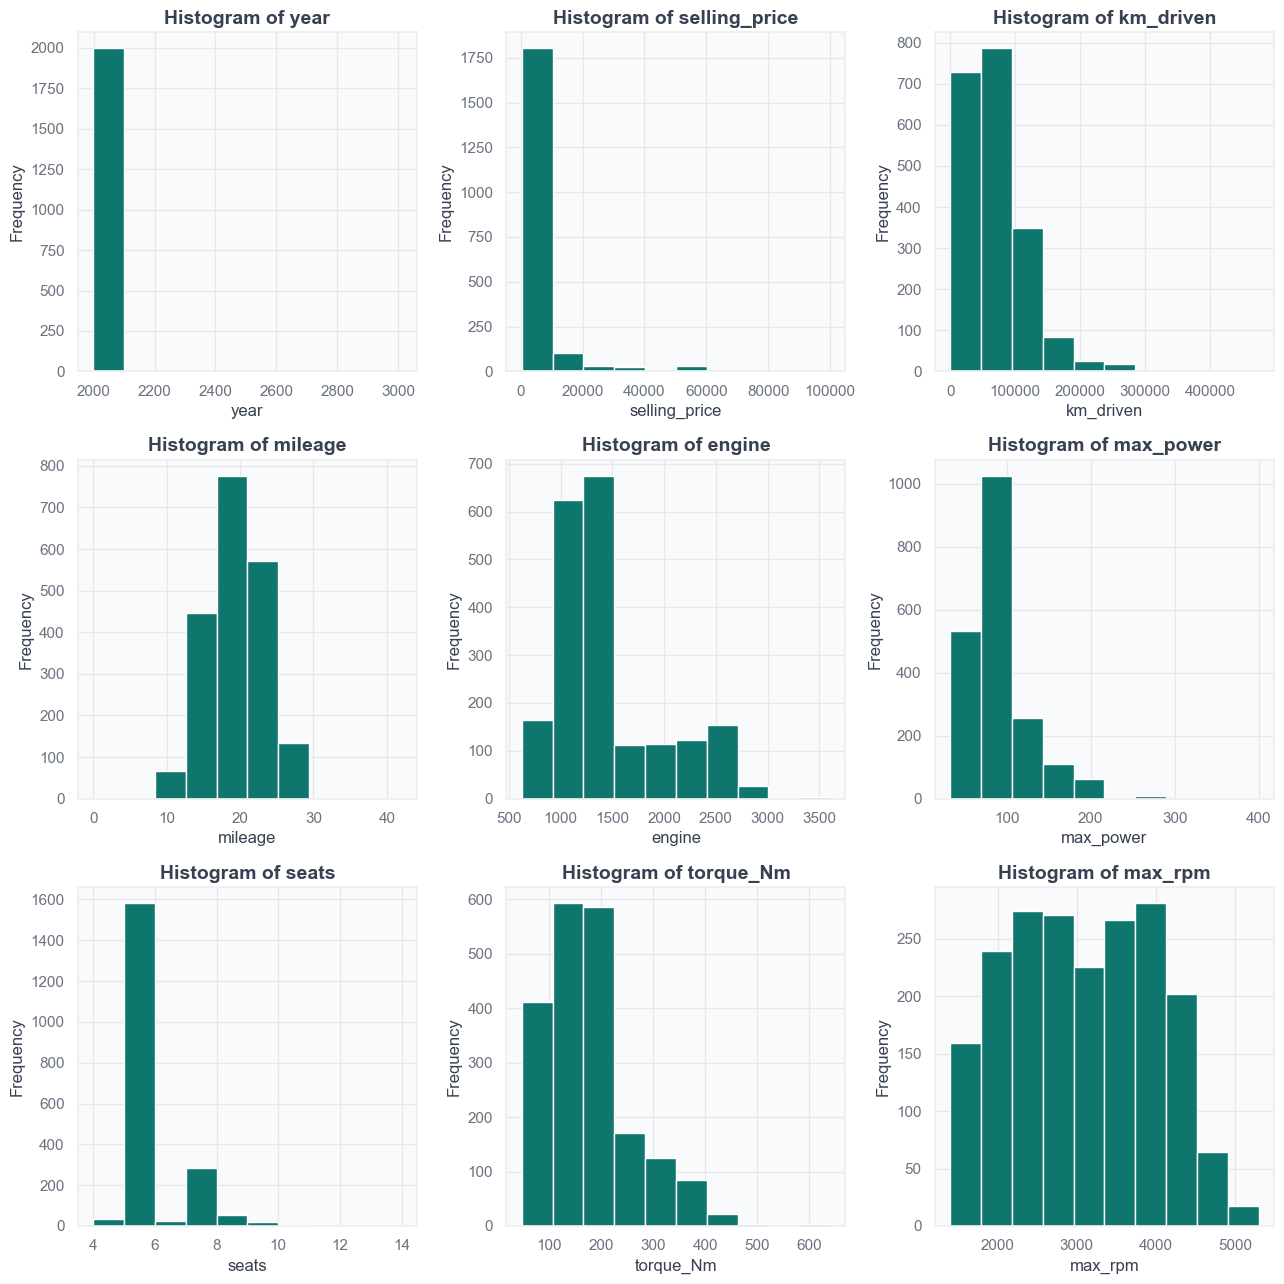

In [76]:
plt.figure(figsize=(13,13))

for i, col in enumerate(num_col, 1):
    plt.subplot(3, 3, i)   
    plt.hist(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

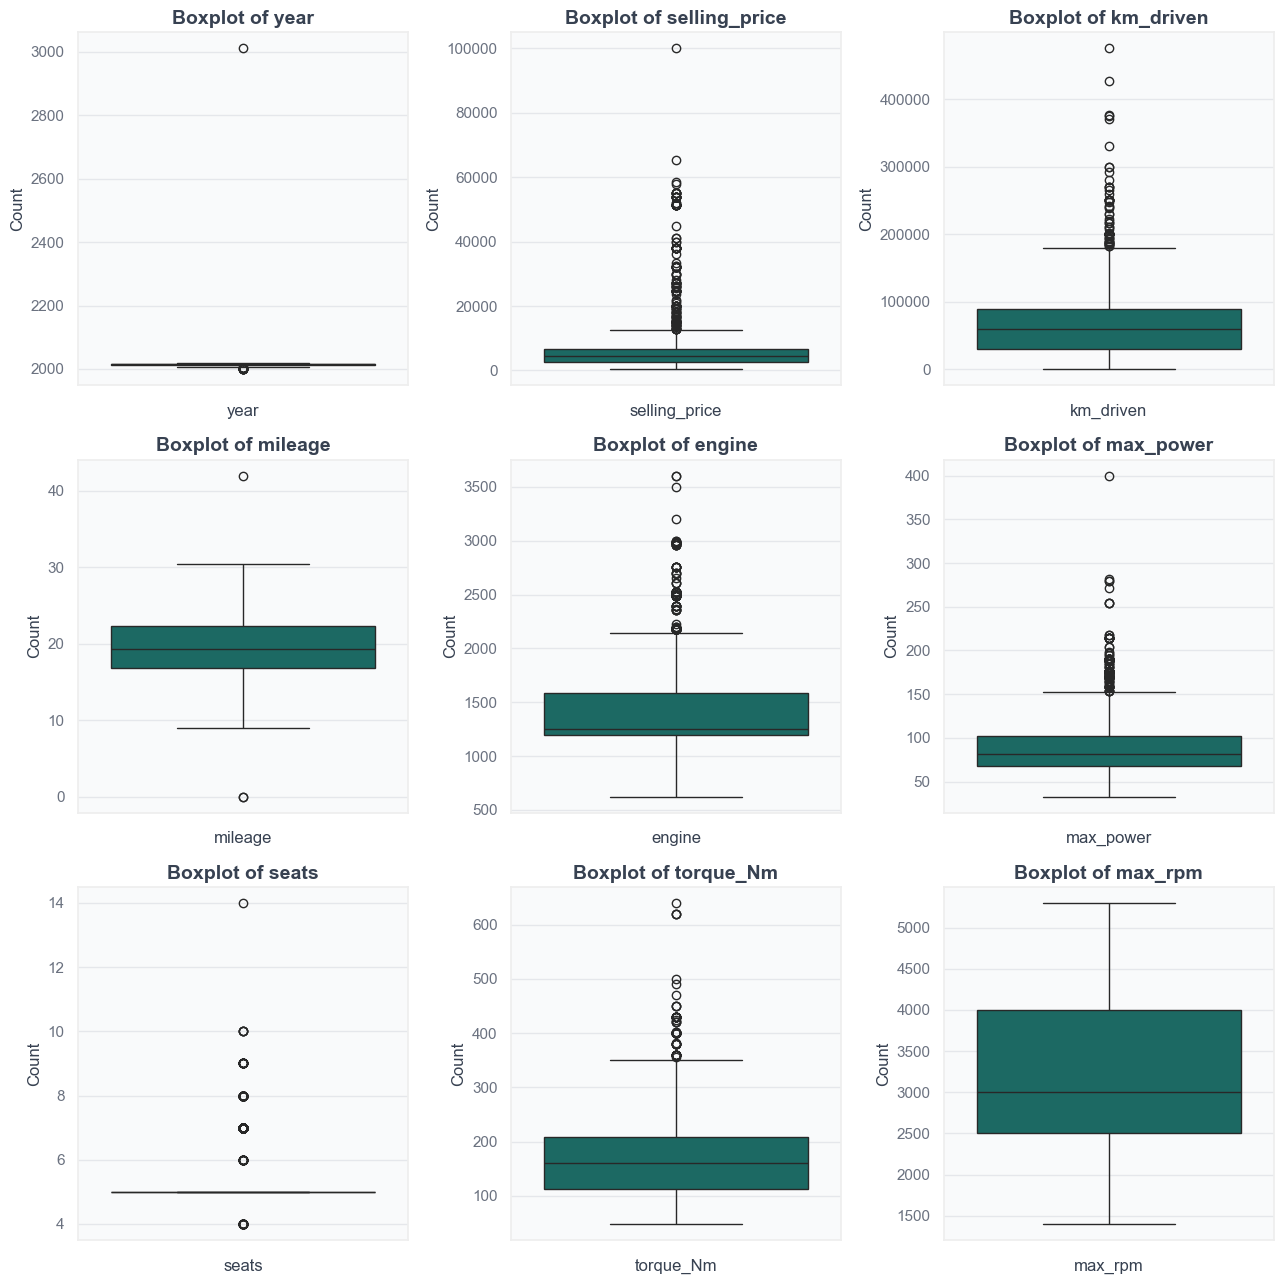

In [77]:
plt.figure(figsize=(13,13))
for i, col in enumerate(num_col, 1):
    plt.subplot(3, 3, i)   
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

Dari graph yang kita lihat di atas, kita dapat menemukan beberapa data extreme yang tidak masuk akal, yaitu data tahun yang melebihi tahun saat ini, mileage yang bernilai 0, dan harga yang sangat mahal diatas rata-rata

In [78]:
# handle extreme values di kolom year
df = df[df['year'] <= 2025]

In [79]:
df[df['mileage'] == 0]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_Nm,max_rpm
83,Tata,2009,1350.0,28900,East,New York,New York City,Petrol,Individual,Manual,Second_Owner,0.0,1172,65.0,5,Y,96.11,3000.0
1365,Hyundai,2009,1200.0,90000,East,New York,New York City,Petrol,Individual,Manual,Second_Owner,0.0,1086,62.0,5,Y,96.10,3000.0


Ternyata terdapat beberapa mobil yang memiliki 0 mileage, dimana sangat mustahil used car namun memiliki 0 mileage

In [80]:
df['mileage'] = df['mileage'].replace(0, np.nan)
df['mileage'] = df.groupby('name')['mileage'].transform(lambda x: x.fillna(x.median()))

In [81]:
#handle max_rpm extreme values
df = df.drop(df[df["max_rpm"] > 20000].index)

In [82]:
# check selling_price extreme values
df[df['selling_price'] >= 60000]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_Nm,max_rpm
505,Audi,2019,65230.0,23600,Central,Missouri,Saint Peters,Petrol,Dealer,Automatic,Test_Drive_Car,15.26,1798,187.74,5,N,320.0,4100.0
881,Volvo,2017,100000.0,30000,East,New York,New York City,Petrol,Individual,Automatic,First_Owner,42.00,1969,400.00,4,Y,640.0,1740.0


Di atas saya melihat bahwa mobil-mobil luxury atau sport car memang memiliki price yang lebih tinggi dari biasanya, namun terdapat outlier yaitu mobil Volvo yang memiliki harga 100000USD yang merupakan sebuah outlier pada data

In [83]:
# handle extreme values
df = df.drop(df[df['selling_price'] > 90000].index)

In [84]:
# check extreme engine cc
df[df['engine'] >= 3000]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_Nm,max_rpm
347,Jeep,2017,41000.0,17000,South,Louisiana,Bossier City,Petrol,Individual,Automatic,First_Owner,9.50,3604,280.0,5,N,347.0,4300.0
686,Jeep,2017,41000.0,17000,East,New York,Auburn,Petrol,Individual,Automatic,First_Owner,9.50,3604,280.0,5,Y,347.0,4300.0
1487,Ford,2016,21000.0,80000,Central,Kansas,Manhattan,Diesel,Individual,Automatic,First_Owner,10.91,3198,197.0,7,N,470.0,2500.0
1937,Mercedes,2009,10000.0,80000,Central,Michigan,Lincoln Park,Petrol,Individual,Automatic,Third_Owner,10.93,3498,272.0,5,N,355.0,4500.0


Mobil dengan cc tinggi sesuai

In [85]:
# check extreme torque Nm
df[df['torque_Nm'] >= 600]

,name,year,selling_price,km_driven,Region,State or Province,City,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,sold,torque_Nm,max_rpm
100,Mercedes,2014,25750.0,70000,West,Colorado,Grand Junction,Diesel,Individual,Automatic,First_Owner,11.74,2987,254.8,5,N,619.0,2400.0
1085,Mercedes,2013,36000.0,50000,Central,Iowa,Burlington,Diesel,Individual,Automatic,First_Owner,11.74,2987,254.8,5,N,619.0,2400.0
1534,Mercedes,2014,32500.0,33000,East,Massachusetts,Everett,Diesel,Individual,Automatic,First_Owner,11.30,2987,254.8,7,N,619.0,2400.0


In [86]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1996.0,2014.043587,3.681098,1999.0,2012.00,2015.00,2017.00,2020.00
selling_price,1996.0,6454.269624,8058.598875,350.0,2750.00,4500.00,6750.00,65230.00
km_driven,1996.0,68854.087174,50131.692656,0.0,30000.00,60000.00,90041.25,475000.00
mileage,1996.0,19.443692,3.882986,9.0,16.78,19.34,22.32,30.46
engine,1996.0,1463.228958,501.041402,624.0,1197.00,1248.00,1582.00,3604.00
max_power,1996.0,91.806511,35.249542,32.8,68.05,82.00,102.00,282.00
seats,1996.0,5.409319,0.950026,4.0,5.00,5.00,5.00,14.00
torque_Nm,1996.0,176.612906,87.452003,48.0,111.80,160.00,209.00,619.00
max_rpm,1996.0,3081.566132,889.344176,1400.0,2500.00,3000.00,4000.00,5300.00


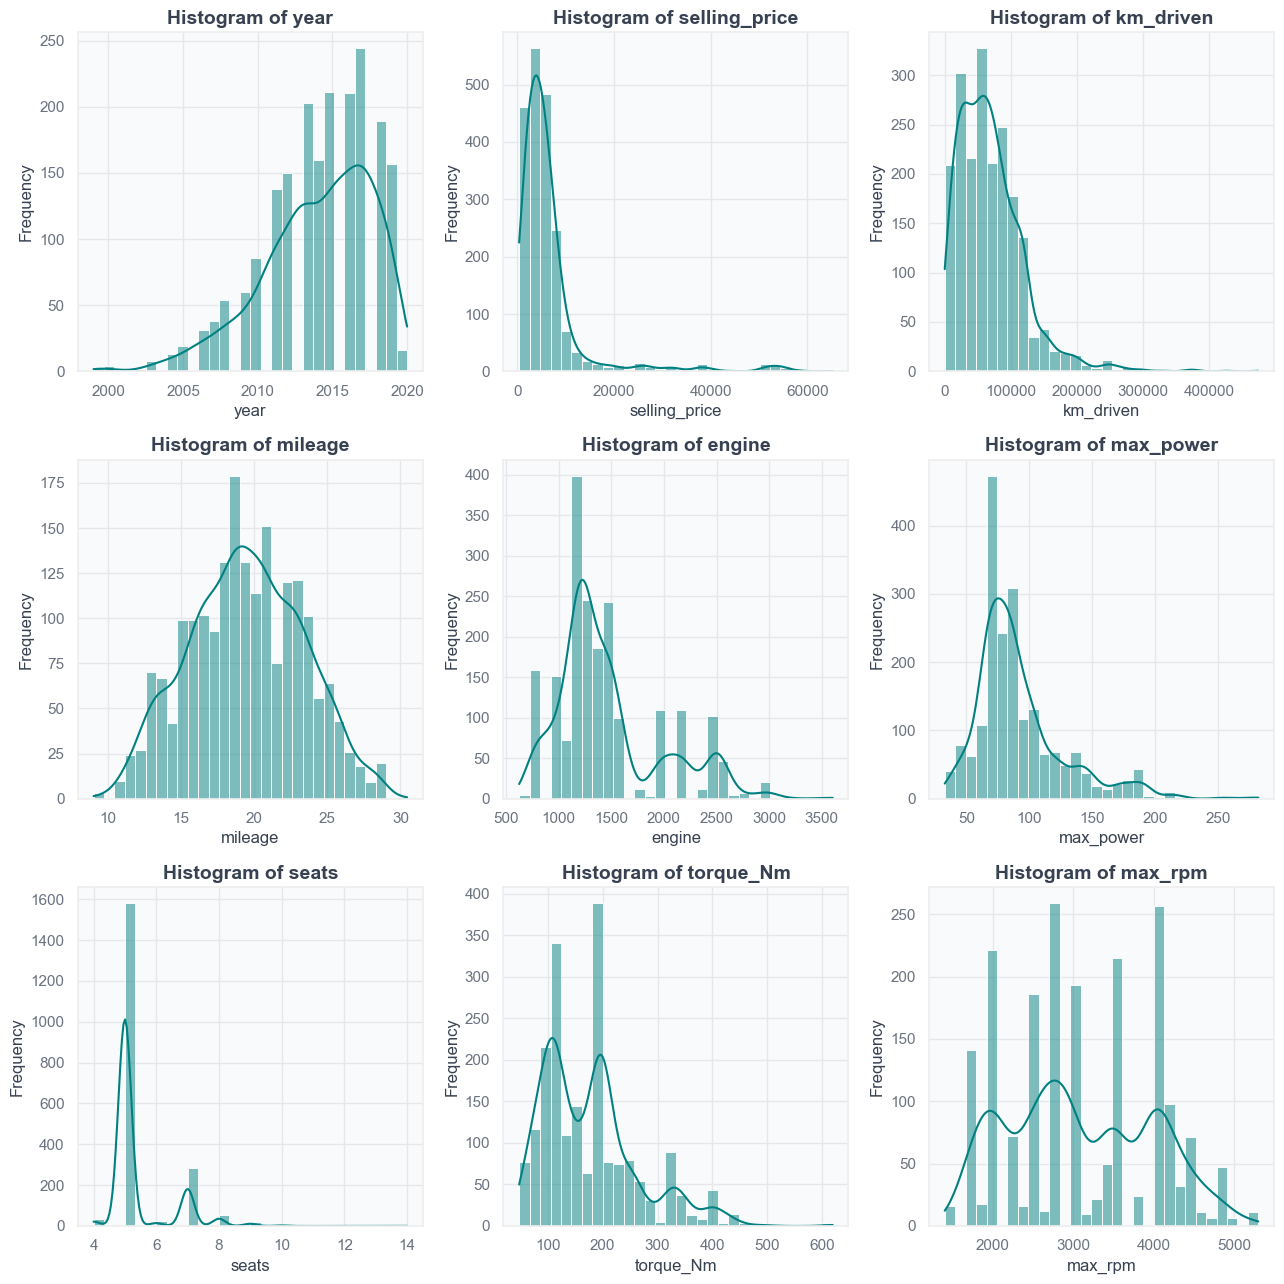

In [87]:
plt.figure(figsize=(13,13))

for i, col in enumerate(num_col, 1):
    plt.subplot(3, 3, i)   
    sns.histplot(df[col], bins=30, kde=True, color="teal")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

Distribusi terlihat membaik dan sesuai

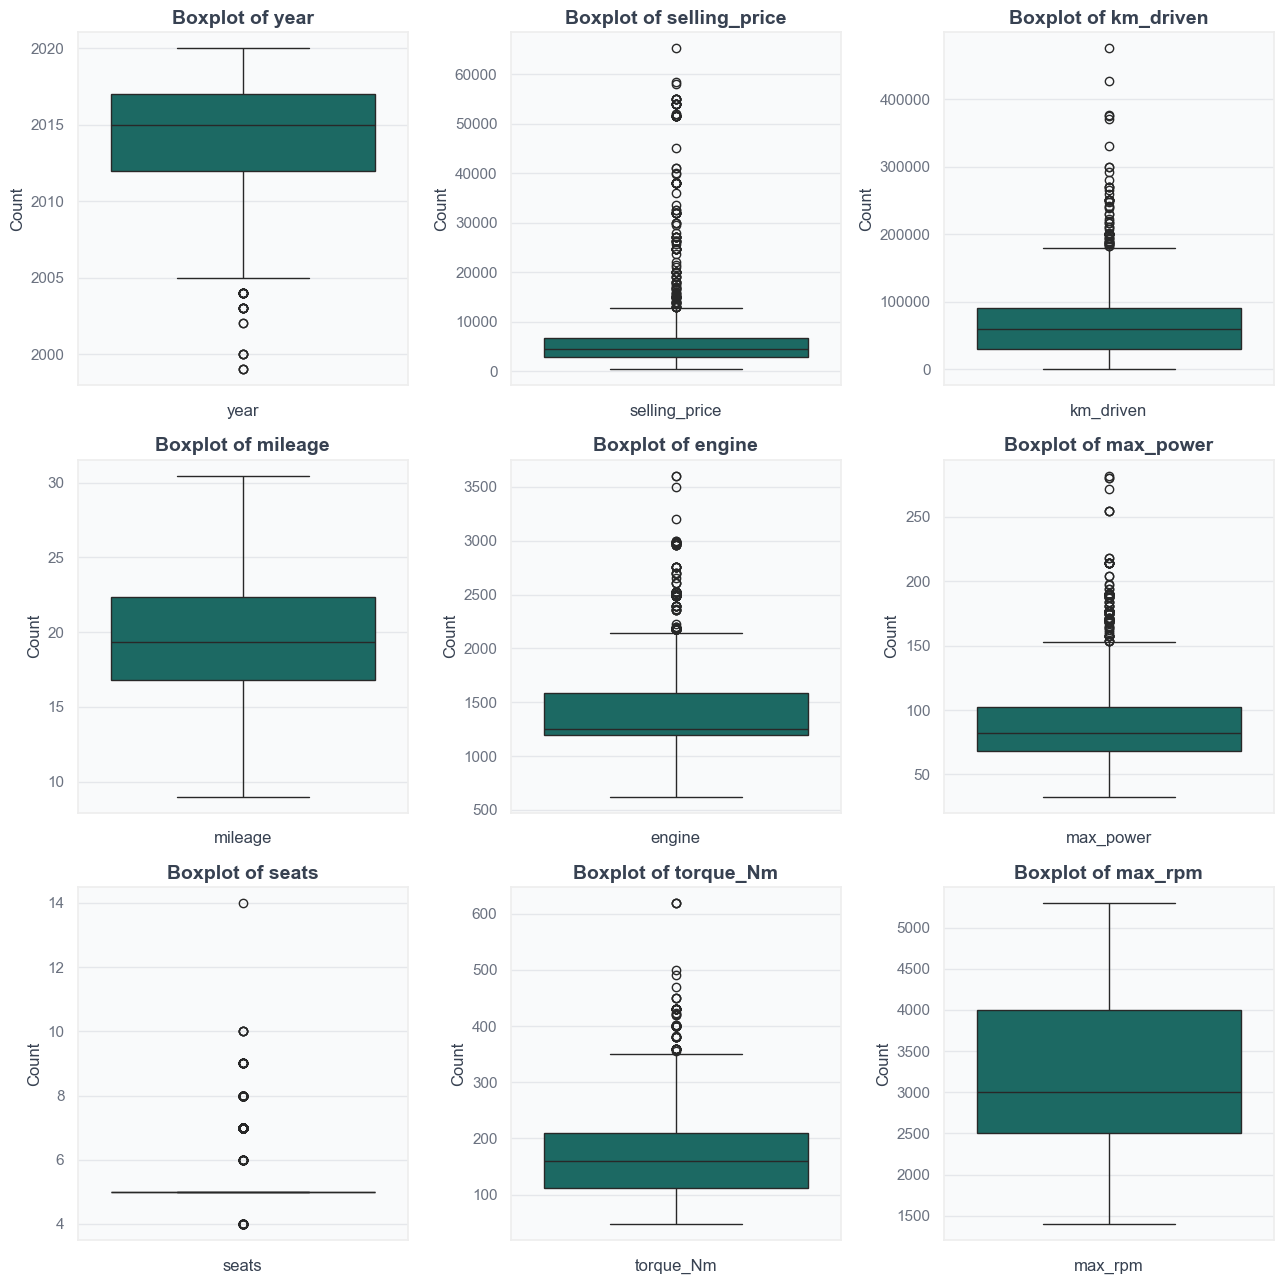

In [88]:
plt.figure(figsize=(13,13))
for i, col in enumerate(num_col, 1):
    plt.subplot(3, 3, i)   
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

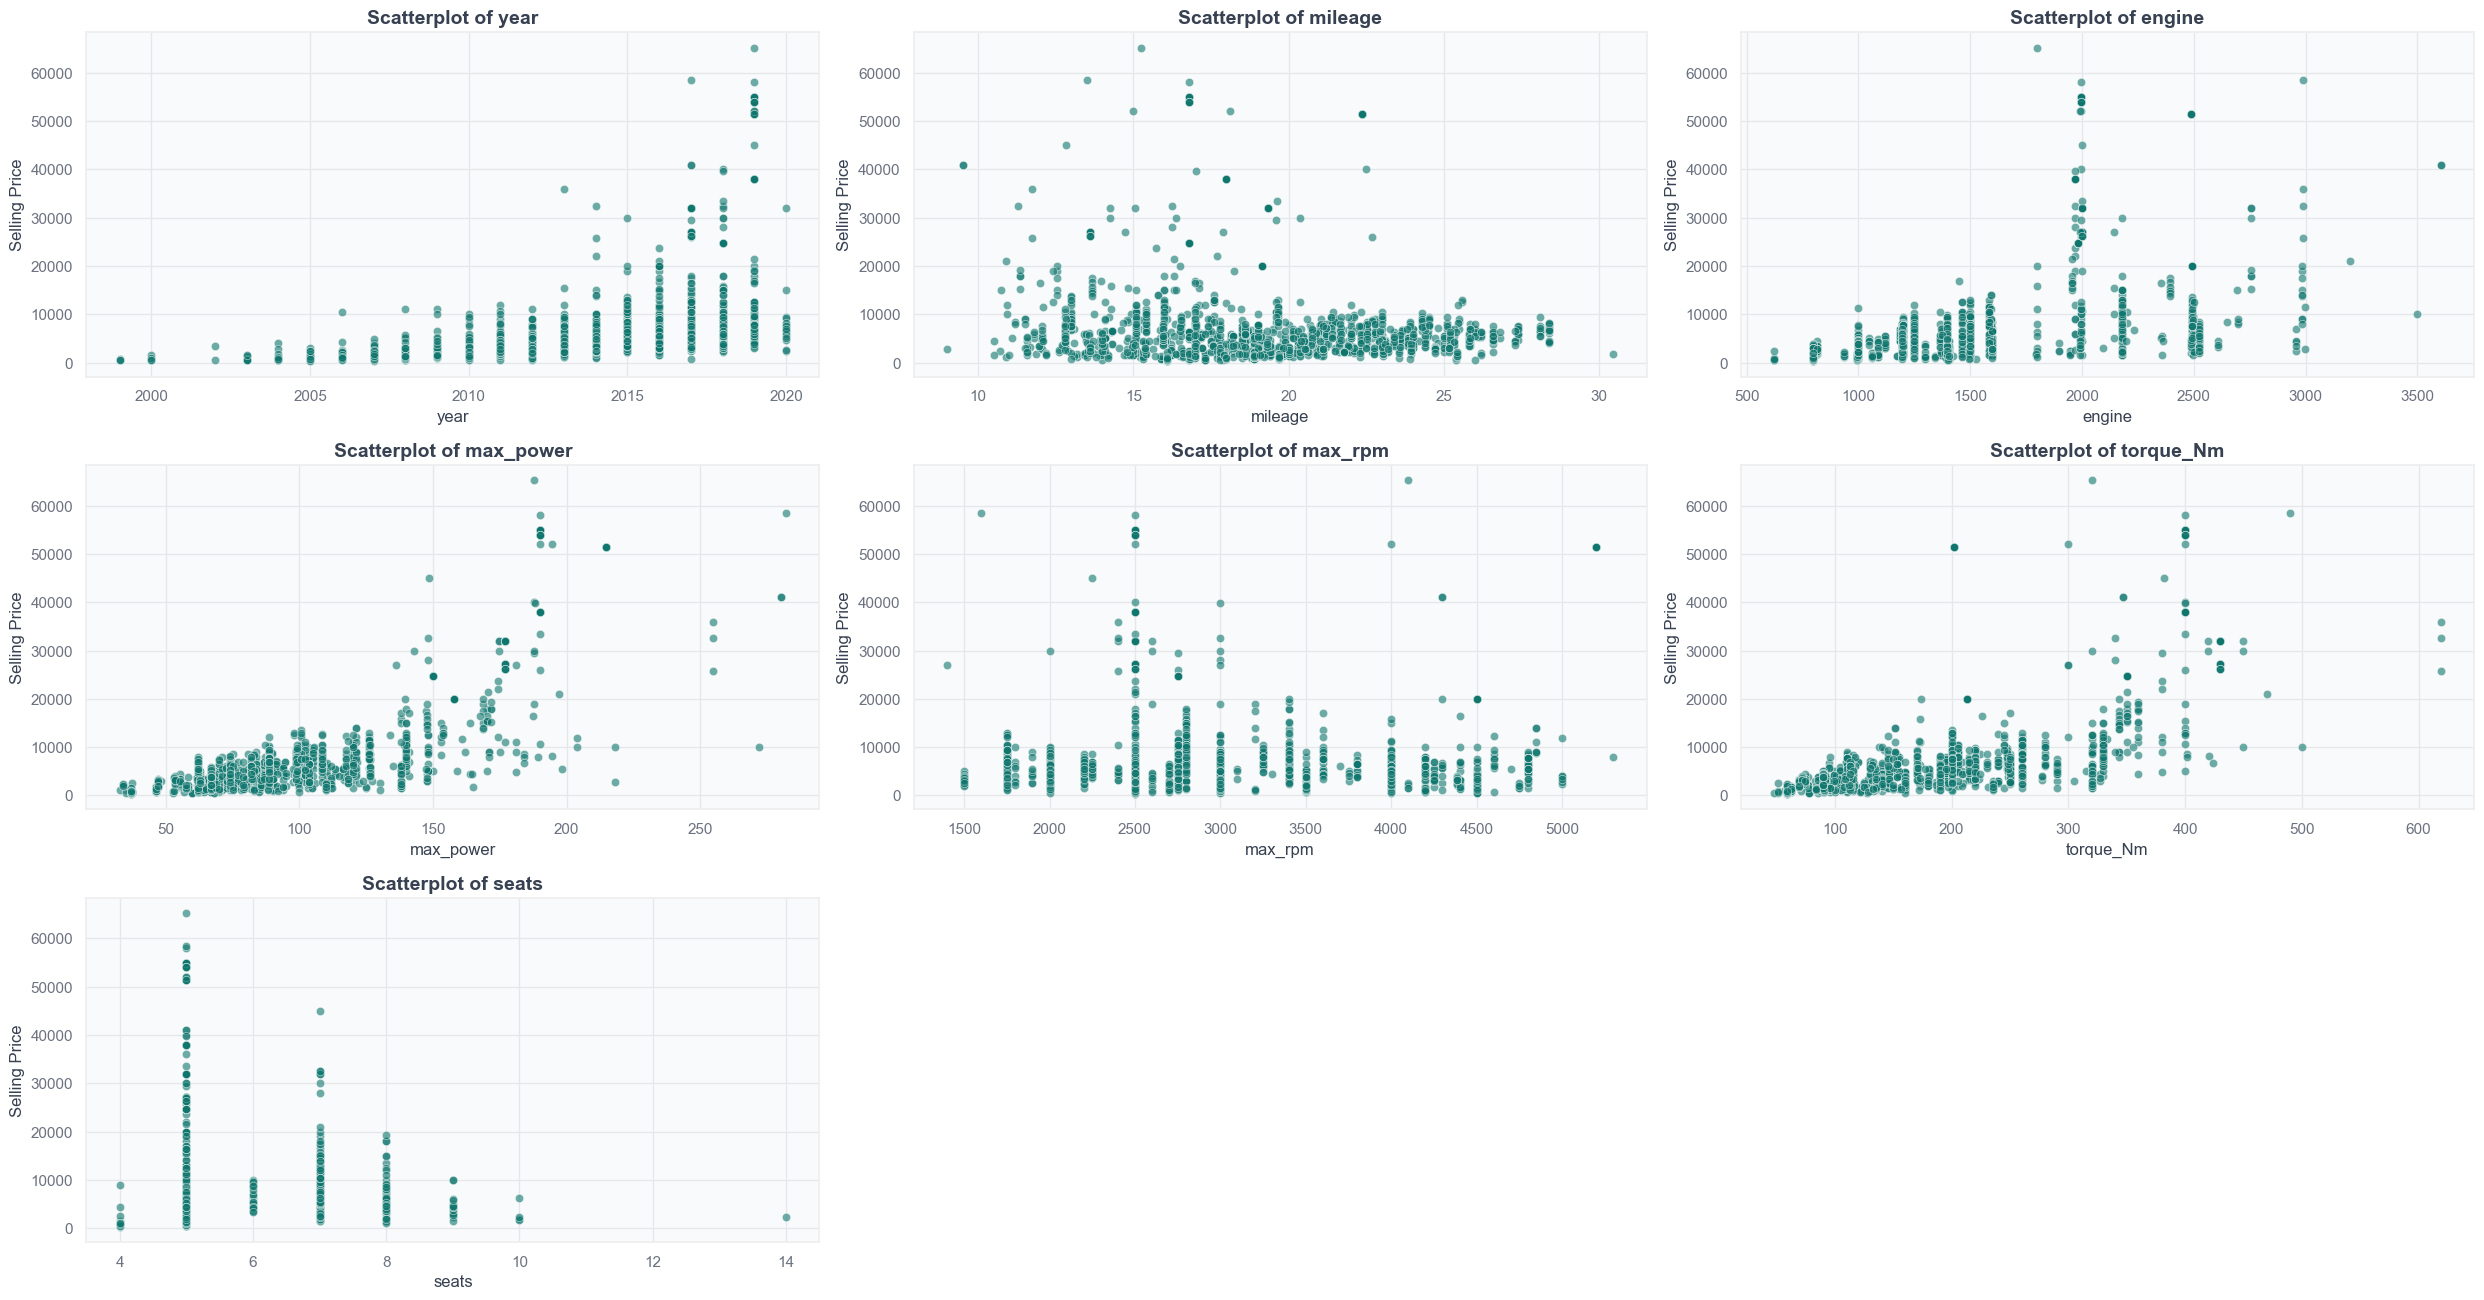

In [89]:
num_col_2 = ['year', 'mileage', 'engine', 'max_power', 'max_rpm', 'torque_Nm', 'seats']
plt.figure(figsize=(25,30))

for i, col in enumerate(num_col_2, 1):
    plt.subplot(7, 3, i)   
    sns.scatterplot(data=df, x=col, y='selling_price', alpha=0.6)
    plt.xlabel(col)
    plt.ylabel("Selling Price")
    plt.title(f"Scatterplot of {col}")
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Correlation Heatmap'}>

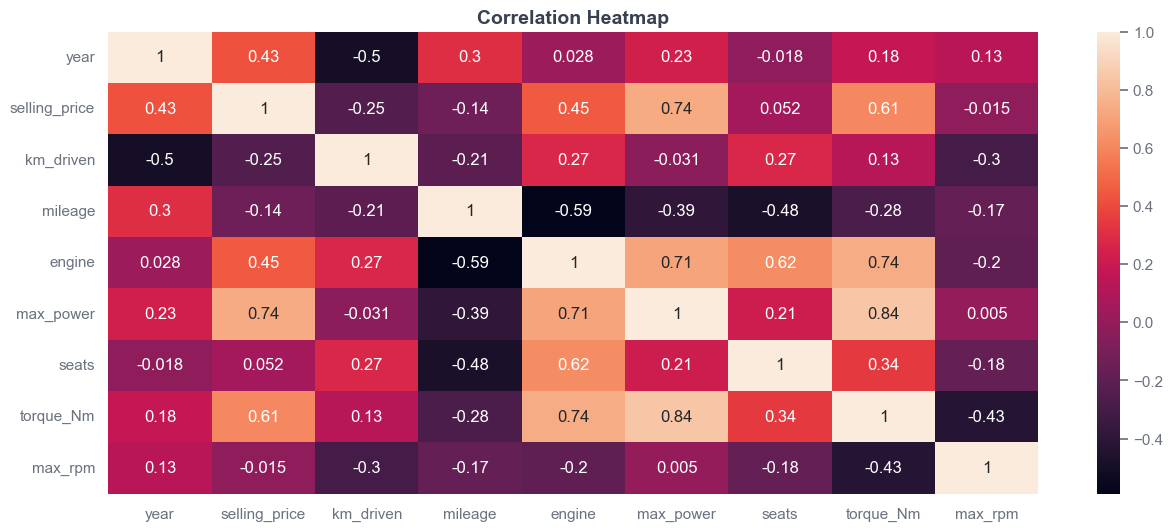

In [90]:
df_corr = (df[num_col]).corr()
plt.figure(figsize=(15,6))
plt.title('Correlation Heatmap')
sns.heatmap(df_corr, annot=True)

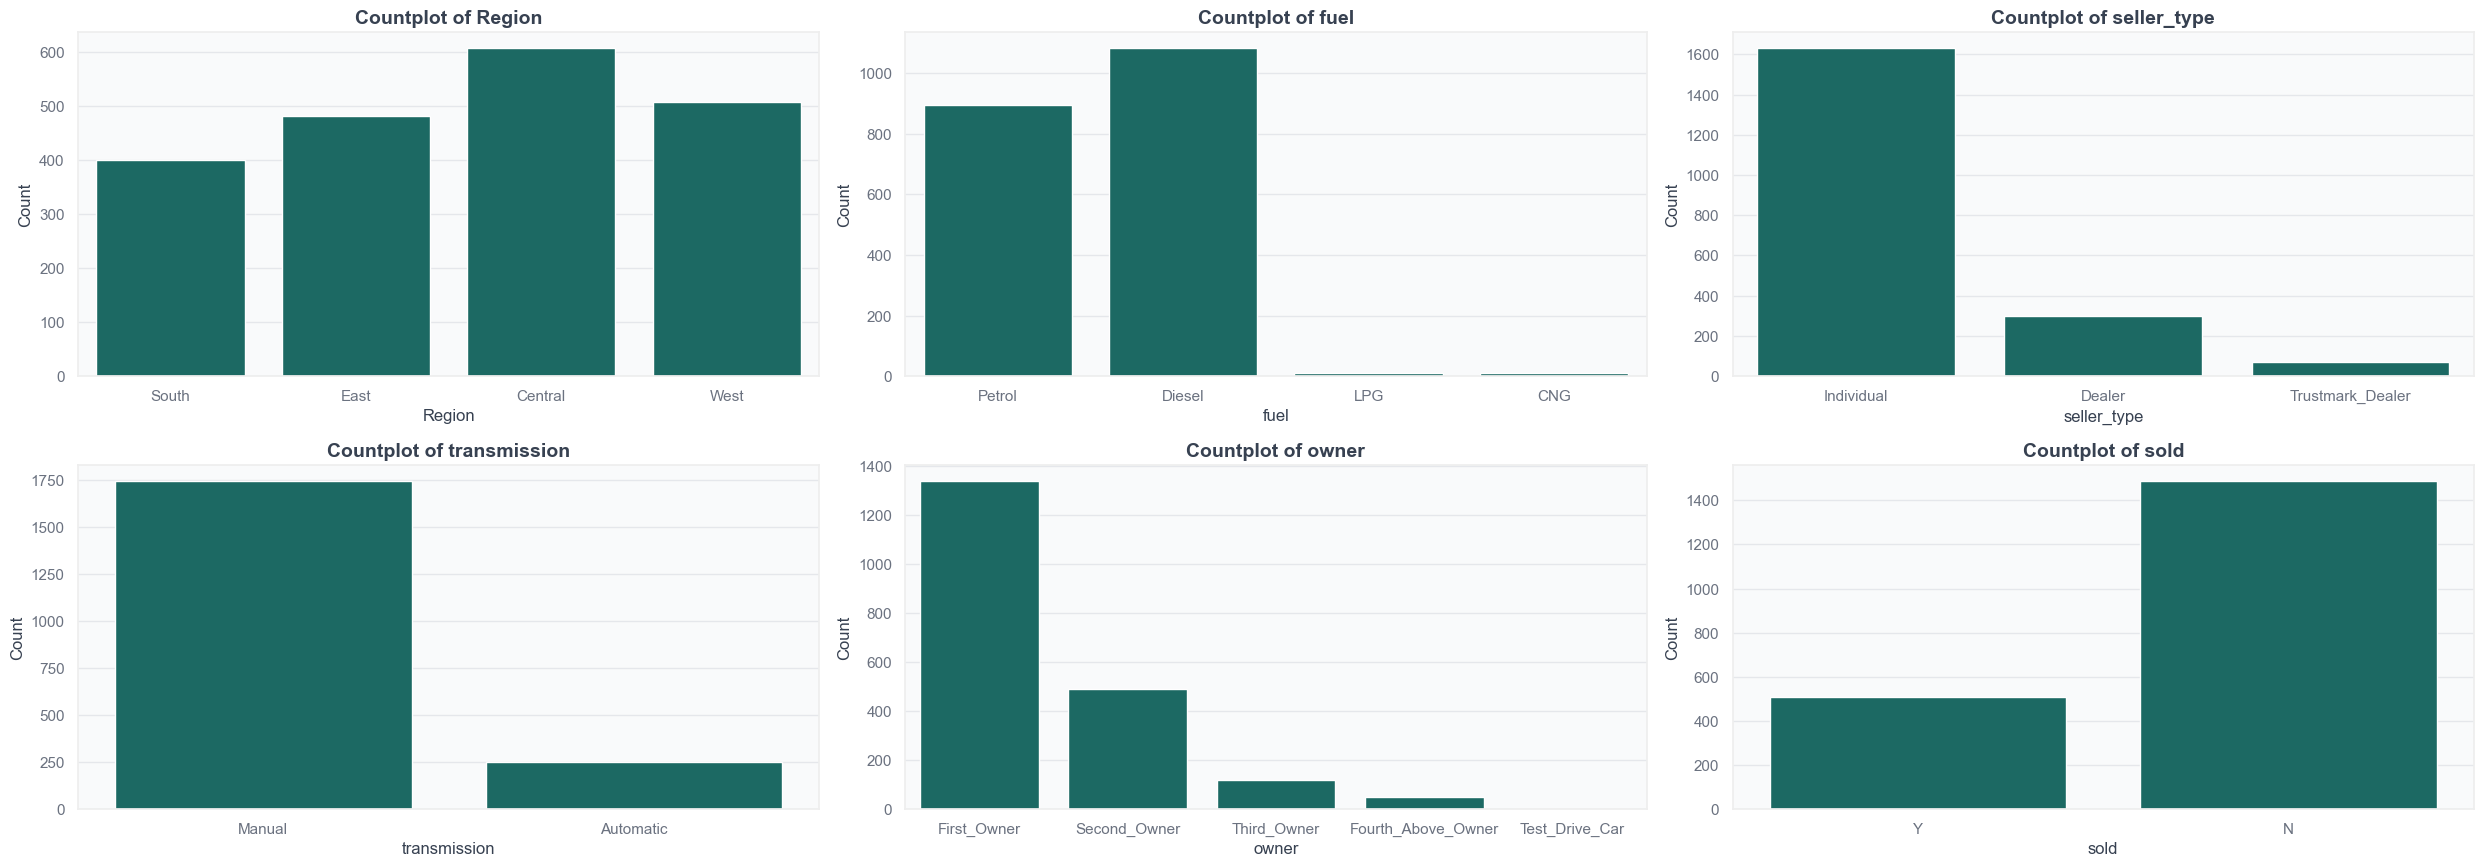

In [91]:
cat_col_2 = ['Region', 'fuel', 'seller_type',
       'transmission', 'owner', 'sold']
plt.figure(figsize=(25,30))

for i, col in enumerate(cat_col_2, 1):
    plt.subplot(7, 3, i)   
    sns.countplot(x=df[col])
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Countplot of {col}")
plt.tight_layout()
plt.show()

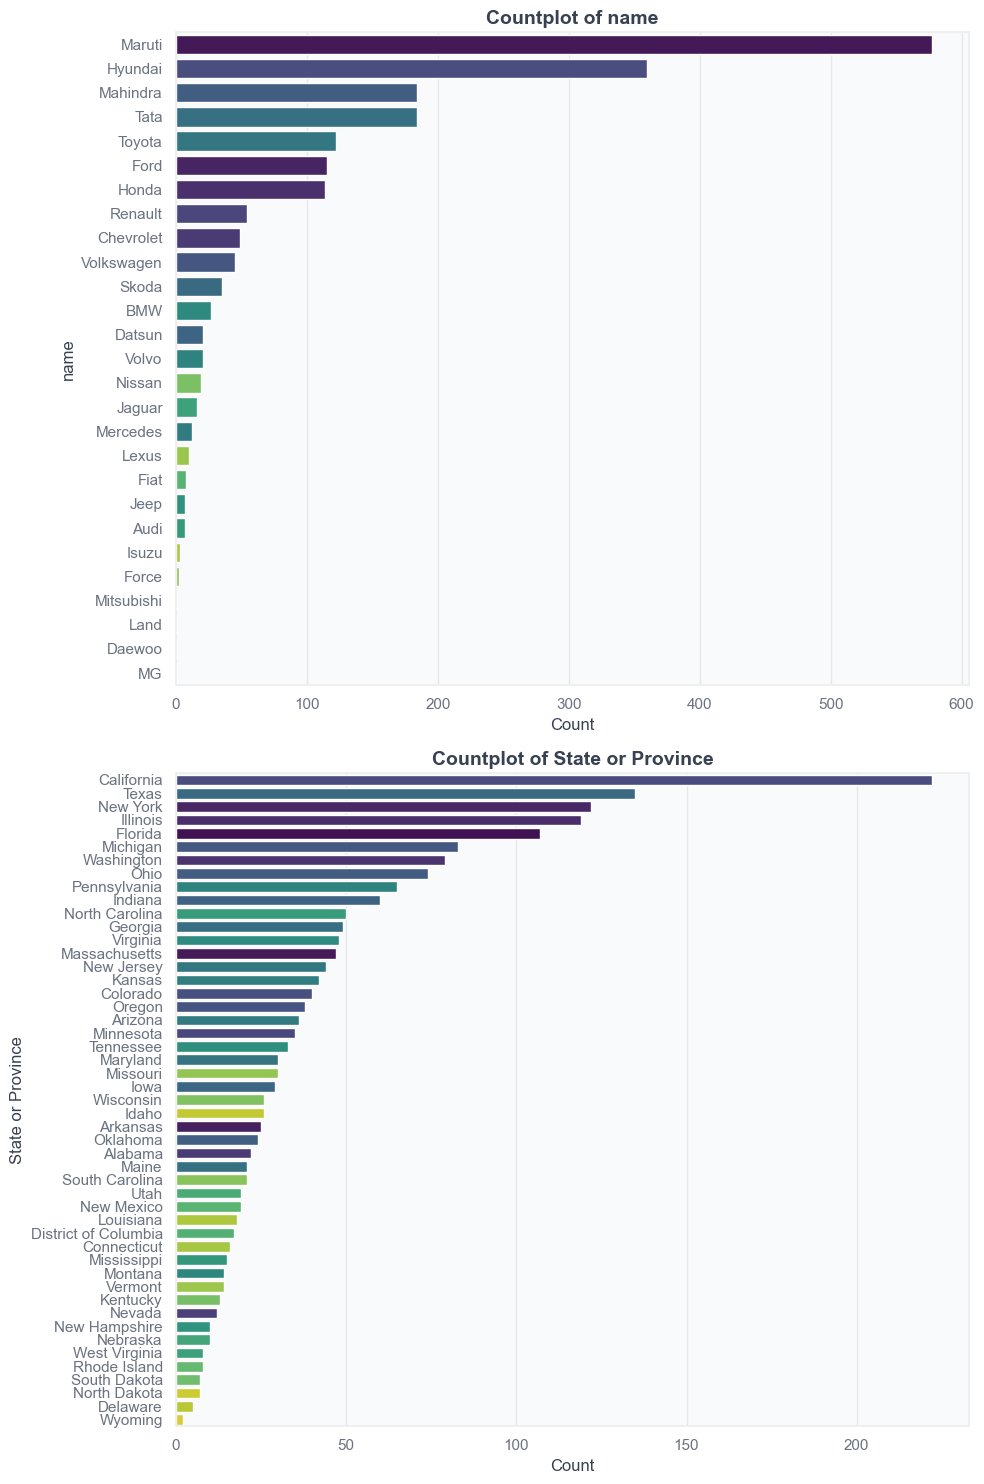

In [92]:
cat_col_3 = ['name', 'State or Province']
plt.figure(figsize=(10, 15))

for i, col in enumerate(cat_col_3, 1):
    plt.subplot(len(cat_col_3), 1, i)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index,
        hue=df[col],           
        legend=False,          
        palette="viridis"      
    )
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.title(f"Countplot of {col}", fontsize=14, fontweight='bold')
    plt.tight_layout()

plt.show()


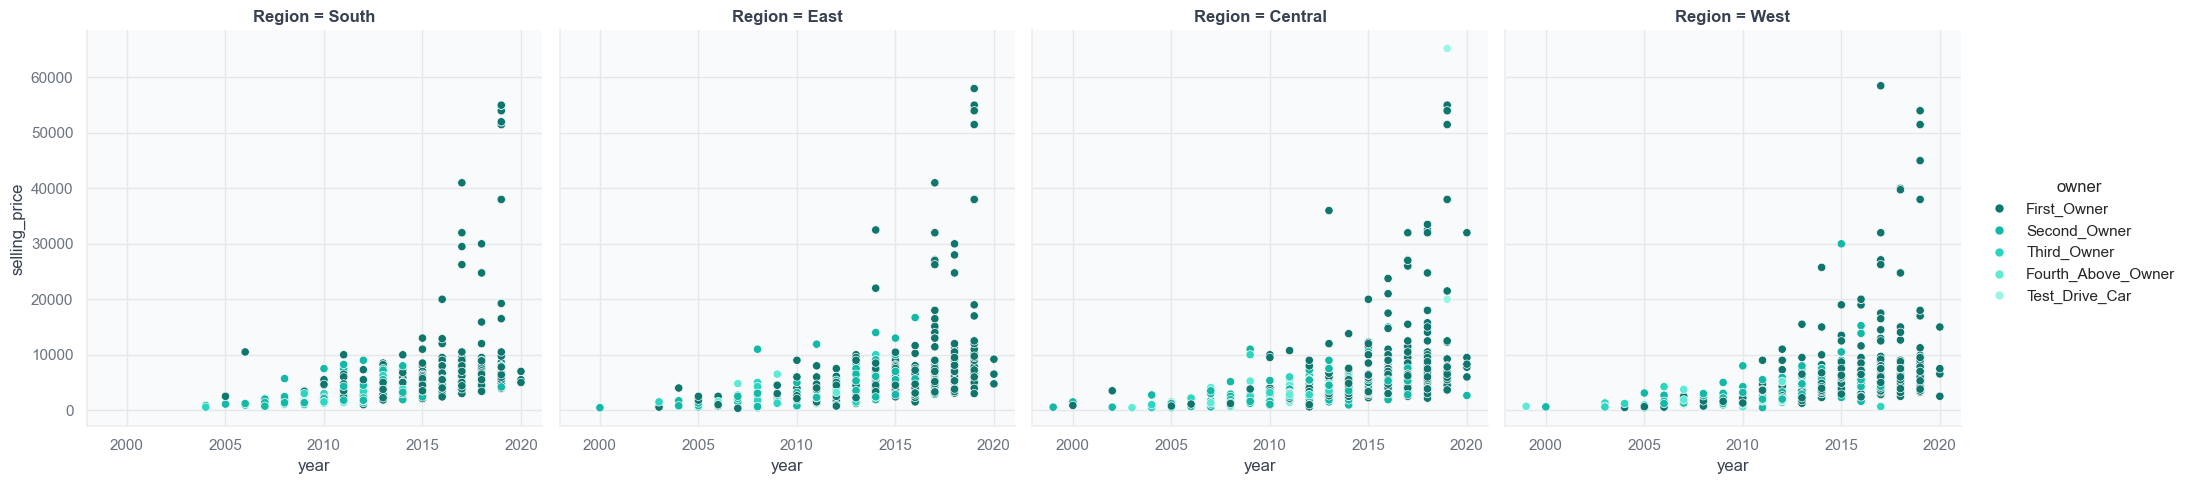

In [93]:
sns.relplot(data=df, x='year', y='selling_price', hue='owner', col='Region')

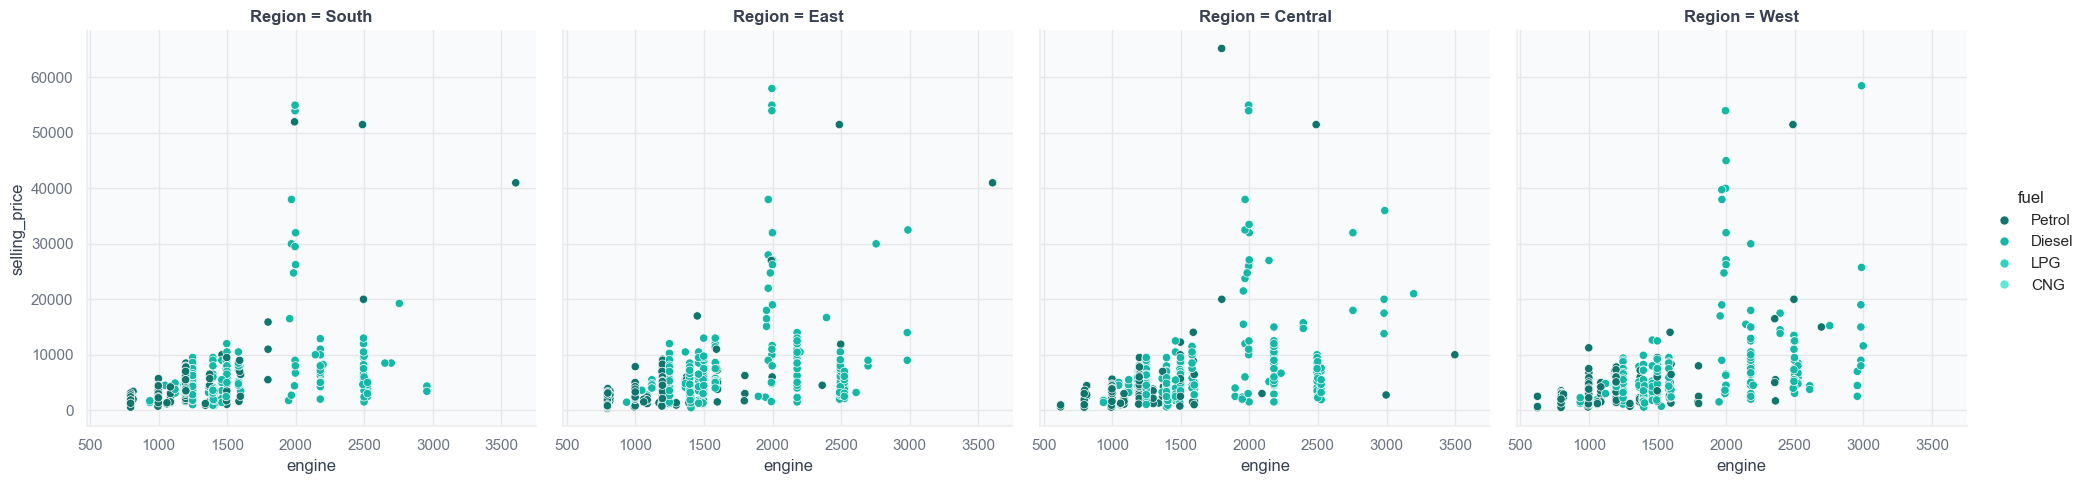

In [94]:
sns.relplot(data=df, x='engine', y='selling_price', hue='fuel', col='Region')

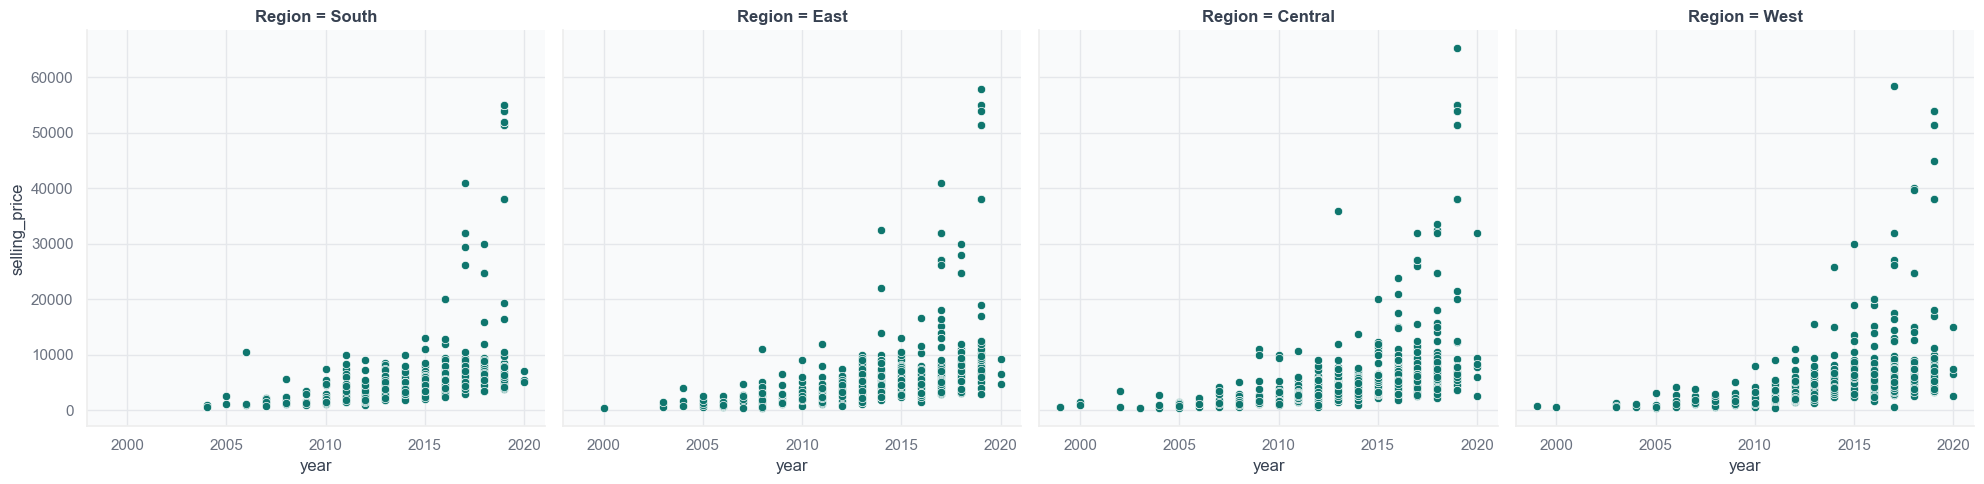

In [95]:
sns.relplot(data=df, x='year', y='selling_price', col='Region')

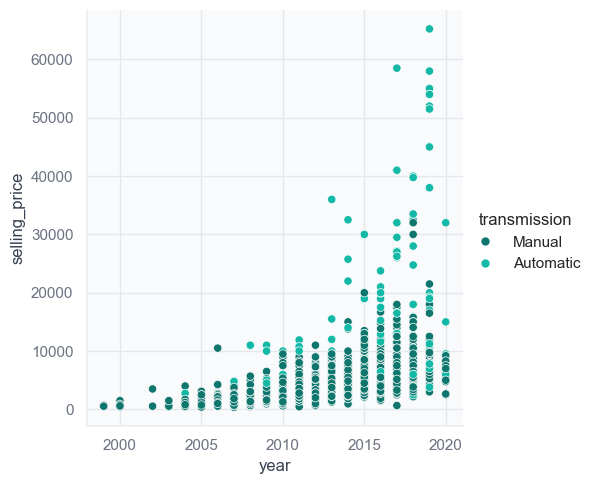

In [96]:
sns.relplot(data=df, x='year', y='selling_price', hue='transmission')

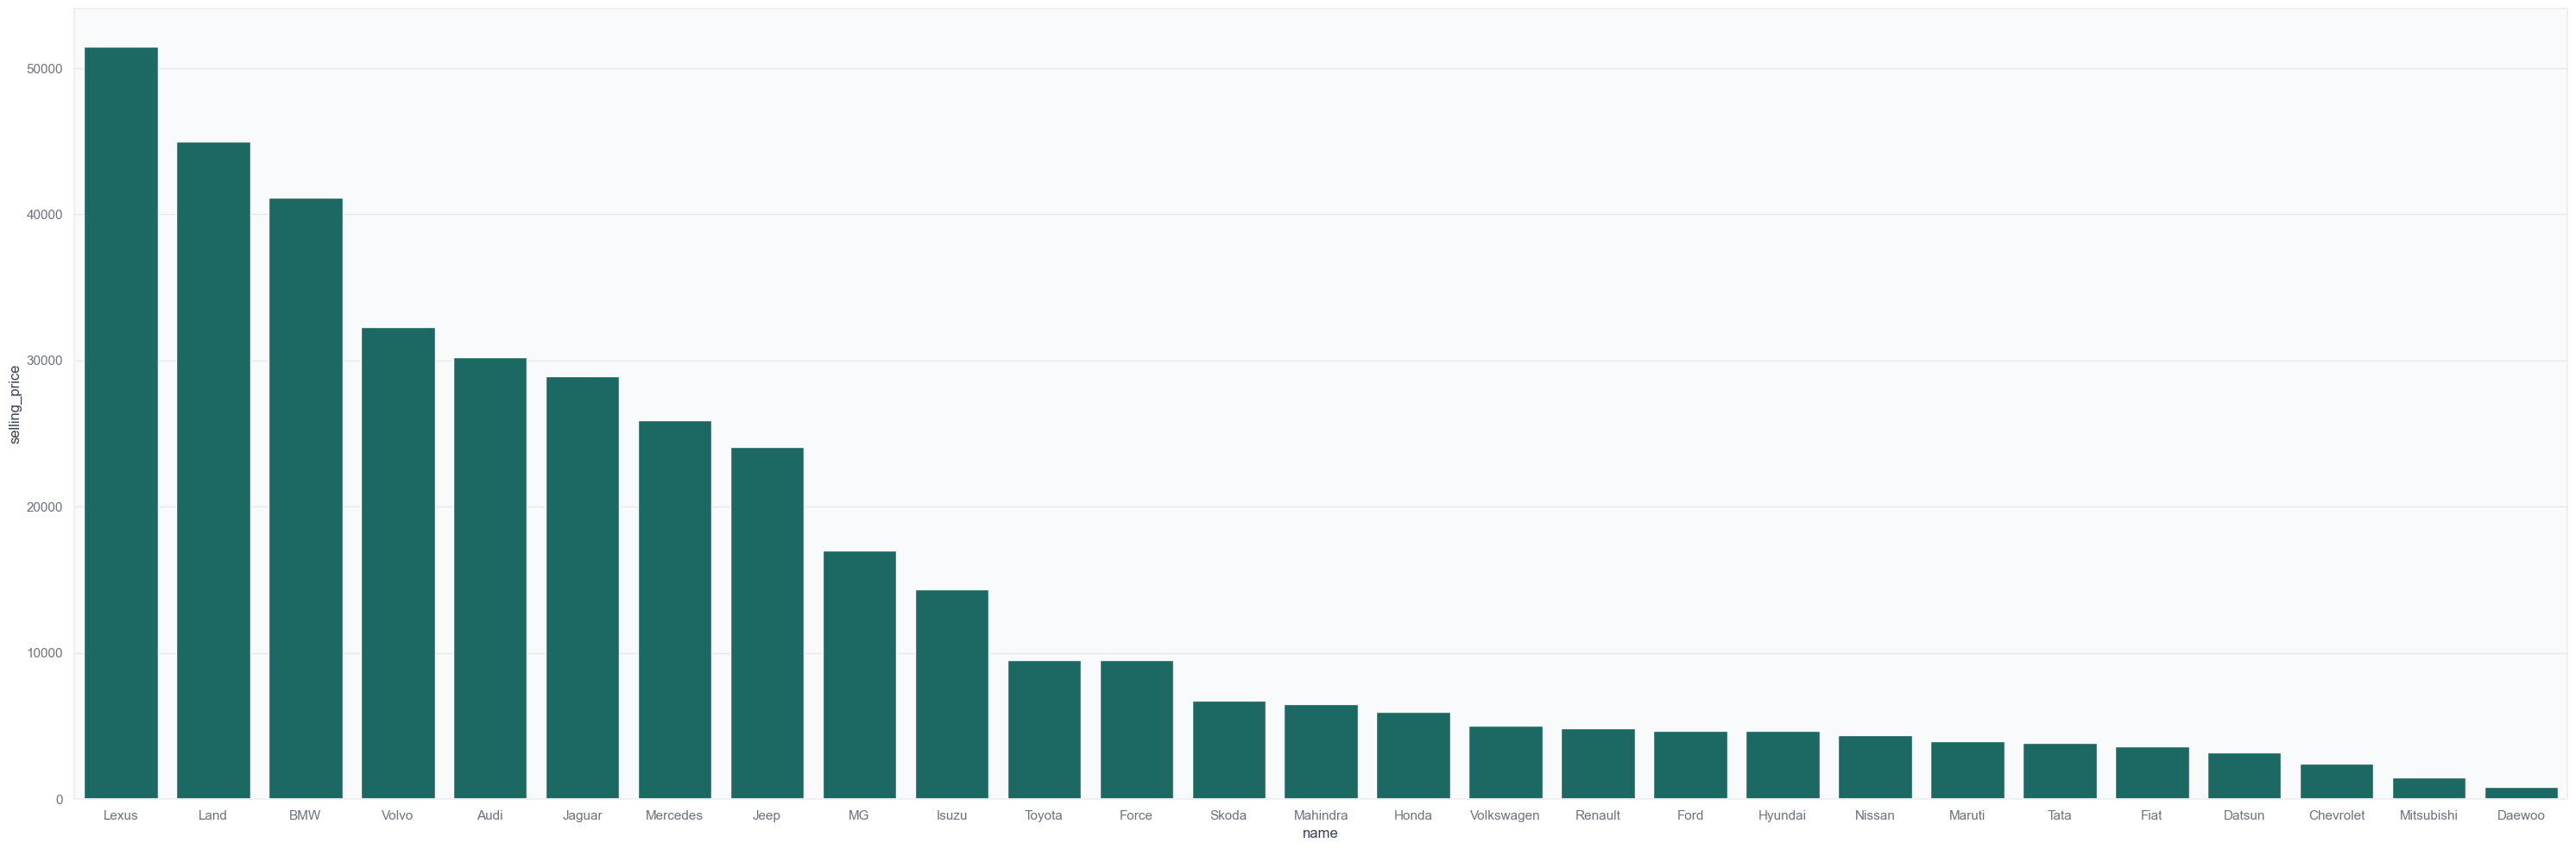

In [97]:
average_price_per_brand = df.groupby('name', as_index=False)['selling_price'].mean().sort_values(by='selling_price', ascending=False)
plt.figure(figsize=(30, 10))
sns.barplot(data=average_price_per_brand, x='name', y='selling_price')
plt.tight_layout()
plt.show()

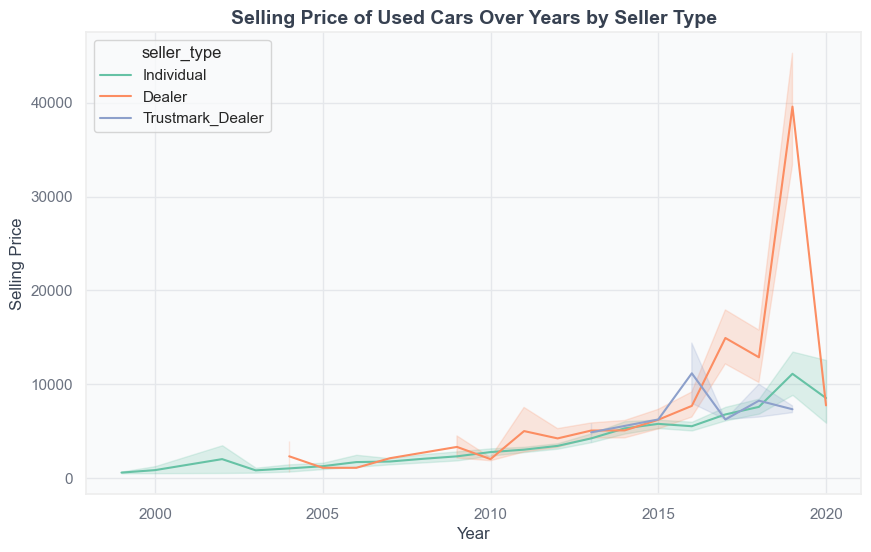

In [98]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='selling_price', hue='seller_type', palette='Set2')
plt.title('Selling Price of Used Cars Over Years by Seller Type')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

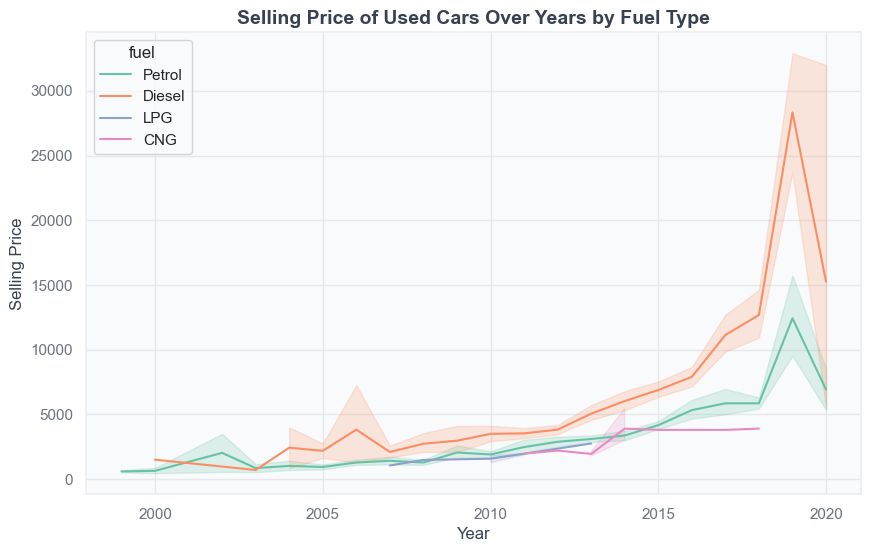

In [99]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='year', y='selling_price', hue='fuel', palette='Set2')
plt.title('Selling Price of Used Cars Over Years by Fuel Type')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

In [100]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats,torque_Nm,max_rpm
count,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000,1996.000000
mean,2014.043587,6454.269624,68854.087174,19.443692,1463.228958,91.806511,5.409319,176.612906,3081.566132
std,3.681098,8058.598875,50131.692656,3.882986,501.041402,35.249542,0.950026,87.452003,889.344176
min,1999.000000,350.000000,0.000000,9.000000,624.000000,32.800000,4.000000,48.000000,1400.000000
25%,2012.000000,2750.000000,30000.000000,16.780000,1197.000000,68.050000,5.000000,111.800000,2500.000000
50%,2015.000000,4500.000000,60000.000000,19.340000,1248.000000,82.000000,5.000000,160.000000,3000.000000
75%,2017.000000,6750.000000,90041.250000,22.320000,1582.000000,102.000000,5.000000,209.000000,4000.000000
max,2020.000000,65230.000000,475000.000000,30.460000,3604.000000,282.000000,14.000000,619.000000,5300.000000


In [101]:
df['transmission'].value_counts()

transmission
Manual       1743
Automatic     253
Name: count, dtype: int64

Findings di EDA
- Dari summary yang kita peroleh pertama kali, terdapat beberapa outlier yang sangat terlihat pada data, namun saya telah handle outlier tersebut
- Saya menemukan bahwa kolom tahun memiliki korelasi yang kuat dengan selling price, ini menandakan bahwa harga mobil dengan tahun baru lebih tinggi dari tahun lama
- Saya juga menemukan bahwa mobil dengan transmission automatic memiliki harga lebih tinggi
- Saya menemukan bahwa di setiap region, ternyata hampir memiliki sifat yang sama. Saya akan menggunakan region saja sebagai fitur lokasi
- Saya juga menemukan bahwa owner memiliki korelasi yang cukup kuat juga, dimana mobil tangan pertama dan mobil test drive memiliki harga yang masih relatif tinggi
- Saya juga menemukan bahwa car brand/name berpengaruh terhadap prices. Mobil luxury/sport memiliki harga yang lebih tinggi dari city cars

#### **B.1 Data Splitting**

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [103]:
X = df.drop(columns=['selling_price', 'State or Province', 'City', 'sold'])
y = df['selling_price']

In [104]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, random_state=42)

print(f"Train size: {len(X_train)}")
print(f"Val size  : {len(X_val)}")
print(f"Test size : {len(X_test)}")

Train size: 1397
Val size  : 199
Test size : 400


In [105]:
X_test 

,name,year,km_driven,Region,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_Nm,max_rpm
1139,Volkswagen,2019,5000,South,Petrol,Individual,Manual,First_Owner,18.78,999,75.00,5,95.0,4300.0
1357,Mahindra,2015,70000,East,Diesel,Individual,Manual,First_Owner,15.40,1997,120.00,7,280.0,2800.0
1703,Ford,2014,54000,Central,Diesel,Dealer,Manual,First_Owner,23.00,1498,98.96,5,205.0,3250.0
548,Renault,2013,75010,East,Diesel,Dealer,Automatic,First_Owner,13.73,1995,148.00,5,320.0,2000.0
1346,Tata,2017,26000,West,Petrol,Individual,Manual,First_Owner,23.84,1199,84.00,5,114.0,3500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,Mercedes,2013,50000,Central,Diesel,Individual,Automatic,First_Owner,11.74,2987,254.80,5,619.0,2400.0
1528,Tata,2013,120000,West,Diesel,Individual,Manual,First_Owner,19.09,1396,69.00,5,135.0,2500.0
1962,Volkswagen,2017,50000,West,Diesel,Individual,Manual,First_Owner,22.27,1498,108.60,5,250.0,3000.0
1312,Toyota,2014,80000,East,Diesel,Individual,Manual,Second_Owner,12.99,2494,100.60,8,200.0,3400.0


In [106]:
X_val

,name,year,km_driven,Region,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_Nm,max_rpm
1781,Volkswagen,2011,49000,East,Petrol,Individual,Manual,First_Owner,15.04,1598,103.60,5,153.00,3800.0
198,Maruti,2008,70000,East,Petrol,Individual,Manual,Third_Owner,19.70,796,46.30,5,62.00,3000.0
1472,Maruti,2010,135000,Central,Diesel,Individual,Manual,Second_Owner,17.80,1248,75.00,5,190.00,2000.0
1708,Maruti,2013,90000,East,Diesel,Individual,Manual,Second_Owner,22.90,1248,74.00,5,190.00,2000.0
432,Maruti,2015,25000,West,Petrol,Individual,Manual,Second_Owner,20.85,1197,83.14,5,115.00,4000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,Mahindra,2014,110000,East,Diesel,Individual,Manual,Second_Owner,20.80,1461,64.10,5,160.00,2000.0
1671,Volkswagen,2015,69000,Central,Diesel,Dealer,Automatic,First_Owner,22.15,1498,108.60,5,250.00,3000.0
789,Mahindra,2018,50000,South,Diesel,Individual,Manual,First_Owner,17.30,1497,121.00,7,300.00,2500.0
398,Hyundai,2015,100000,West,Petrol,Individual,Manual,Second_Owner,19.81,1086,68.05,5,99.04,4500.0


#### **B.2 Feature Engineering**

In [107]:
# year feature scaling
X_train['age'] = 2025 - X_train['year']
X_val['age']  = 2025 - X_val['year']
X_test['age']  = 2025 - X_test['year']
X_train = X_train.drop(columns=['year'])
X_val   = X_val.drop(columns=['year'])
X_test  = X_test.drop(columns=['year'])

In [108]:
# numeric feature scaling
scale_col = ['mileage', 'engine', 'max_power', 'max_rpm', 'torque_Nm', 'seats', 'age', 'km_driven']
scaler = RobustScaler()

X_train[scale_col] = scaler.fit_transform(X_train[scale_col])
X_val[scale_col] = scaler.transform(X_val[scale_col])
X_test[scale_col] = scaler.transform(X_test[scale_col])

In [109]:
from sklearn.preprocessing import OneHotEncoder
#categorical col encoding
cat_col_encode = ['name', 'fuel', 'seller_type', 'owner', 'Region']
oh_encoder = OneHotEncoder(sparse_output=False, drop=None, handle_unknown='ignore')
encoded_train = oh_encoder.fit_transform(X_train[cat_col_encode])
encoded_val = oh_encoder.transform(X_val[cat_col_encode])
encoded_test = oh_encoder.transform(X_test[cat_col_encode])

encoded_train_df = pd.DataFrame(encoded_train, columns=oh_encoder.get_feature_names_out(cat_col_encode), index=X_train.index)
encoded_val_df = pd.DataFrame(encoded_val, columns=oh_encoder.get_feature_names_out(cat_col_encode), index=X_val.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=oh_encoder.get_feature_names_out(cat_col_encode), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cat_col_encode), encoded_train_df], axis=1)
X_val = pd.concat([X_val.drop(columns=cat_col_encode), encoded_val_df], axis=1)
X_test = pd.concat([X_test.drop(columns=cat_col_encode), encoded_test_df], axis=1)

In [110]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_train['transmission'] = le.fit_transform(X_train['transmission'])
X_val['transmission'] = le.transform(X_val['transmission'])
X_test['transmission'] = le.transform(X_test['transmission'])
map = dict(zip(le.classes_, le.transform(le.classes_)))
map

{'Automatic': np.int64(0), 'Manual': np.int64(1)}

In [111]:
X_train.shape, X_val.shape, X_test.shape

((1397, 51), (199, 51), (400, 51))

In [112]:
X_val

,km_driven,transmission,mileage,engine,max_power,seats,torque_Nm,max_rpm,age,name_Audi,...,seller_type_Trustmark_Dealer,owner_First_Owner,owner_Fourth_Above_Owner,owner_Second_Owner,owner_Test_Drive_Car,owner_Third_Owner,Region_Central,Region_East,Region_South,Region_West
1781,-0.183333,1,-0.768953,0.909091,0.636230,0.0,-0.075107,0.533333,0.8,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
198,0.166667,1,0.072202,-1.174026,-1.051546,0.0,-1.051502,0.000000,1.4,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1472,1.250000,1,-0.270758,0.000000,-0.206186,0.0,0.321888,-0.666667,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1708,0.500000,1,0.649819,0.000000,-0.235641,0.0,0.321888,-0.666667,0.4,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
432,-0.583333,1,0.279783,-0.132468,0.033579,0.0,-0.482833,0.666667,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,0.833333,1,0.270758,0.553247,-0.527246,0.0,0.000000,-0.666667,0.2,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1671,0.150000,0,0.514440,0.649351,0.783505,0.0,0.965665,0.000000,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
789,-0.166667,1,-0.361011,0.646753,1.148748,2.0,1.502146,-0.333333,-0.6,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
398,0.666667,1,0.092058,-0.420779,-0.410898,0.0,-0.654077,1.000000,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [113]:
X_test

,km_driven,transmission,mileage,engine,max_power,seats,torque_Nm,max_rpm,age,name_Audi,...,seller_type_Trustmark_Dealer,owner_First_Owner,owner_Fourth_Above_Owner,owner_Second_Owner,owner_Test_Drive_Car,owner_Third_Owner,Region_Central,Region_East,Region_South,Region_West
1139,-0.916667,1,-0.093863,-0.646753,-0.206186,0.0,-0.697425,0.866667,-0.8,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1357,0.166667,1,-0.703971,1.945455,1.119293,2.0,1.287554,-0.133333,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1703,-0.100000,1,0.667870,0.649351,0.499558,0.0,0.482833,0.166667,0.2,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
548,0.250167,0,-1.005415,1.940260,1.944035,0.0,1.716738,-0.666667,0.4,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1346,-0.566667,1,0.819495,-0.127273,0.058910,0.0,-0.493562,0.333333,-0.4,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,-0.166667,0,-1.364621,4.516883,5.089838,0.0,4.924893,-0.400000,0.4,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1528,1.000000,1,-0.037906,0.384416,-0.382916,0.0,-0.268240,-0.333333,0.4,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1962,-0.166667,1,0.536101,0.649351,0.783505,0.0,0.965665,0.000000,-0.4,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1312,0.333333,1,-1.138989,3.236364,0.547865,3.0,0.429185,0.266667,0.2,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [114]:
y_train_log = np.log1p(y_train)

In [115]:
y_val_log = np.log1p(y_val)

In [116]:
y_val.shape

(199,)

In [117]:
y_test.shape

(400,)

#### **B.3 Model 1 (Base Model) Training**

In [118]:
import tensorflow as tf
import os, random
import numpy as np
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

In [119]:
model_1 = Sequential([
    Dense(102, activation='relu', input_shape=(51,)),
    Dense(204, activation='relu'),
    Dense(408, activation='relu'),Dropout(0.2),
    Dense(1, activation='linear'),
])

c:\Users\Tuf Gaming\buat-coding\env\dl\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [120]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 102)            │         5,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 204)            │        21,012 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 408)            │        83,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 408)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           409 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,365 (431.11 KB)

 Trainable params: 110,365 (431.11 KB)

 Non-trainable params: 0 (0.00 B)

In [121]:
from tensorflow.keras.losses import Huber
def rmse(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

In [122]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True
)

In [123]:
model_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.R2Score()]
)

In [124]:
history = model_1.fit(
    X_train, y_train_log,
    epochs = 100,
    batch_size = 32,
    validation_data = (X_val, y_val_log),
    # callbacks = [early_stop],
    verbose = 1,
    shuffle = True,
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 15.2289 - mean_absolute_error: 2.8807 - r2_score: -23.5516 - root_mean_squared_error: 3.9024 - val_loss: 1.5735 - val_mean_absolute_error: 0.9511 - val_r2_score: -1.0560 - val_root_mean_squared_error: 1.2544
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8746 - mean_absolute_error: 0.6959 - r2_score: -0.4100 - root_mean_squared_error: 0.9352 - val_loss: 0.4613 - val_mean_absolute_error: 0.5014 - val_r2_score: 0.3972 - val_root_mean_squared_error: 0.6792
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4539 - mean_absolute_error: 0.5071 - r2_score: 0.2682 - root_mean_squared_error: 0.6738 - val_loss: 0.2861 - val_mean_absolute_error: 0.4013 - val_r2_score: 0.6262 - val_root_mean_squared_error: 0.5348
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3611 - mean_absolute_error: 0.4531 - r2_score: 0.4178 - root_mean_squared_error: 0.6009 - val_loss: 0.1951 - val_mean_absolute_error: 0.3256 - v

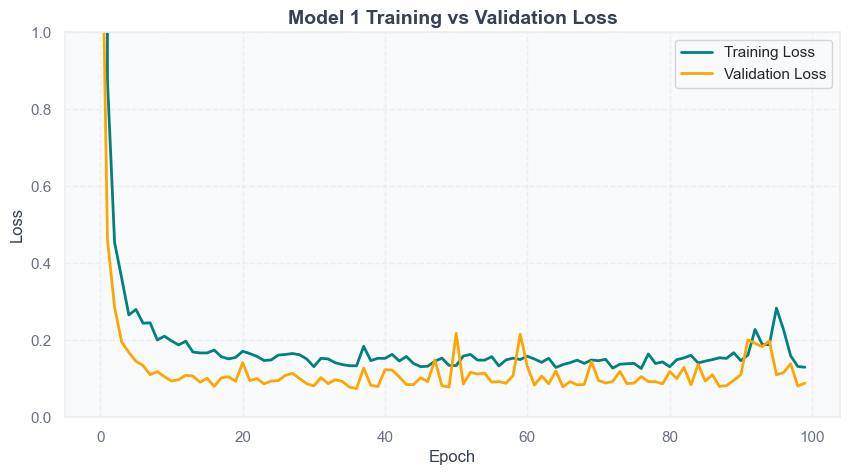

In [125]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss', color='teal', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model 1 Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

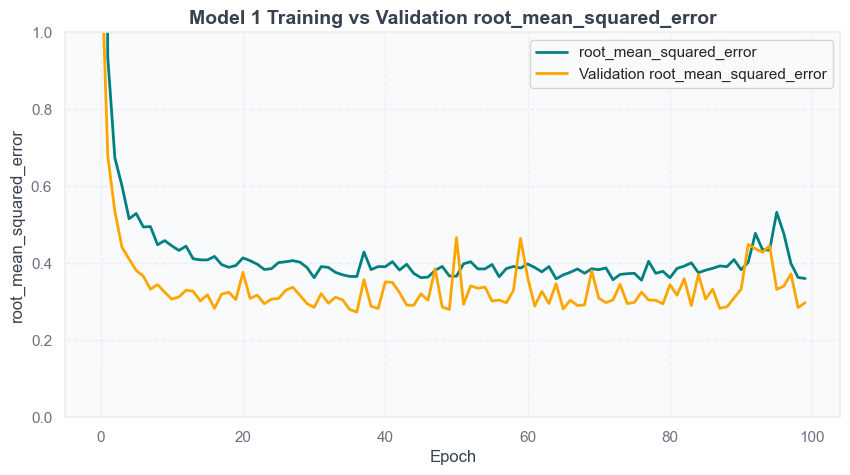

In [126]:
plt.figure(figsize=(10,5))
plt.plot(history.history['root_mean_squared_error'], label='root_mean_squared_error', color='teal', linewidth=2)
plt.plot(history.history['val_root_mean_squared_error'], label='Validation root_mean_squared_error', color='orange', linewidth=2)
plt.title('Model 1 Training vs Validation root_mean_squared_error', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('root_mean_squared_error')
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [127]:
train_loss_model1 = min(history.history['loss'])
val_loss_model1 = min(history.history['val_loss'])

print('best train loss model 1:', train_loss_model1)
print('best val loss model 1:', val_loss_model1)

best train loss model 1: 0.12674656510353088
best val loss model 1: 0.07464971393346786


In [128]:
avg_train_loss_model1 = np.mean(history.history['loss'])
avg_val_loss_model1 = np.mean(history.history['val_loss'])
print(f"Average Training Loss: {avg_train_loss_model1:.4f}")
print(f"Average Validation Loss: {avg_val_loss_model1:.4f}")

Average Training Loss: 0.3233
Average Validation Loss: 0.1290


Pada model pertama ini, saya mencoba untuk menggunakan tetap 3 Hidden layer namun menggunakan fungsi aktivasi yang berbeda, yaitu 'ReLU'. ReLU adalah Rectified Linear Unit, ini merupakan sebuah activation function non linear yang digunakan pada hidden layer. Tujuan dari ReLU adalah memperkenalkan non linearitas ke dalam model, dengan tujuannya adalah untuk memungkinkan layer mempelajari complex patern dari data. "The ReLU function is a piecewise linear function that outputs the input directly if it is positive; otherwise, it outputs zero". Dari beberapa sumber yang saya baca, ReLU dapat mengatasi vanishing gradient problem yang dapat terjadi dalam model kita. ReLU berbeda dari sigmoid dan tanh function, ReLU dapat mengatasi vanishing gradient problem. 
<br><br>
Dari graph diatas, model nampak cepat belajar. Berdasarkan hasil eksperimen awal, model menunjukkan volatilitas yang tinggi pada kurva validasi dengan grafik loss yang tampak tidak stabil. Pada penggunaan learning rate sebesar 0.01, model mengalami fluktuasi tajam yang mengindikasikan bahwa langkah optimasi terlalu besar sehingga model terus melompati titik minimum global. Setelah dilakukan penyesuaian dengan menurunkan learning rate menjadi 0.001, grafik loss mulai menunjukkan tren penurunan yang lebih halus dan teratur. Teramati pada sekitar epoch ke-40, model berhasil mencapai titik konvergensi yang lebih stabil, meskipun tetap terdapat gap antara training dan validation loss yang mengonfirmasi bahwa arsitektur ReLU murni pada Model 1 ini memerlukan regulasi tambahan agar tidak terlalu cepat mengalami kejenuhan. dan berhasil memberikan hasil R2 0.88 dengan MAE 2114 USD.

#### **C.1 Model 2 Training**

In [129]:
model_2 = Sequential([
    Dense(256, activation='sigmoid', input_shape=(51,)),
    Dense(128, activation='sigmoid'),
    Dense(104, activation='relu'),
    Dense(1, activation='linear'),
])

c:\Users\Tuf Gaming\buat-coding\env\dl\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [130]:
model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsoluteError(), tf.keras.metrics.R2Score()]
)

In [131]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 104)            │        13,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           105 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,729 (233.32 KB)

 Trainable params: 59,729 (233.32 KB)

 Non-trainable params: 0 (0.00 B)

In [132]:
history2 = model_2.fit(
    X_train, y_train_log,
    epochs = 100,
    batch_size = 32,
    validation_data = (X_val, y_val_log),
    # callbacks = [early_stop],
    verbose = 1,
    shuffle = True,
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 16.4508 - mean_absolute_error: 3.0170 - r2_score: -25.5216 - root_mean_squared_error: 4.0560 - val_loss: 0.7678 - val_mean_absolute_error: 0.6634 - val_r2_score: -0.0033 - val_root_mean_squared_error: 0.8762
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6106 - mean_absolute_error: 0.5869 - r2_score: 0.0156 - root_mean_squared_error: 0.7814 - val_loss: 0.6428 - val_mean_absolute_error: 0.6202 - val_r2_score: 0.1600 - val_root_mean_squared_error: 0.8018
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4990 - mean_absolute_error: 0.5258 - r2_score: 0.1956 - root_mean_squared_error: 0.7064 - val_loss: 0.5598 - val_mean_absolute_error: 0.5805 - val_r2_score: 0.2685 - val_root_mean_squared_error: 0.7482
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.4255 - mean_absolute_error: 0.4842 - r2_score: 0.3140 - root_mean_squared_error: 0.6523 - val_loss: 0.4532 - val_mean_absolute_error: 0.5198 - va

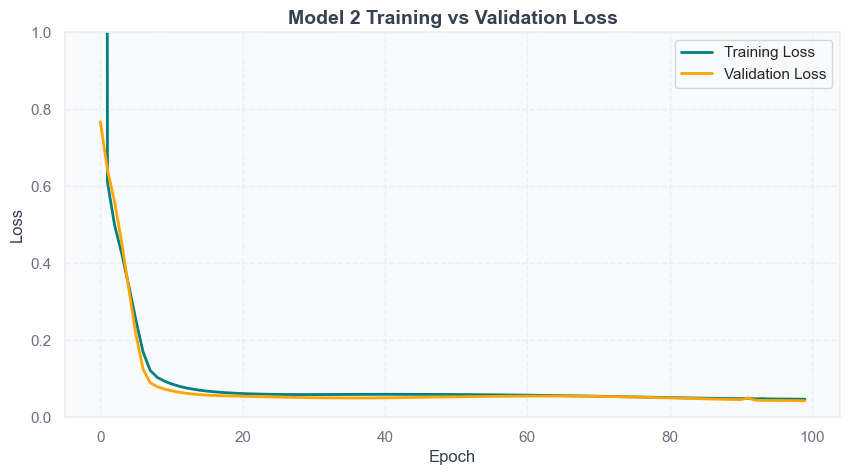

In [133]:
plt.figure(figsize=(10,5))
plt.plot(history2.history['loss'], label='Training Loss', color='teal', linewidth=2)
plt.plot(history2.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model 2 Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

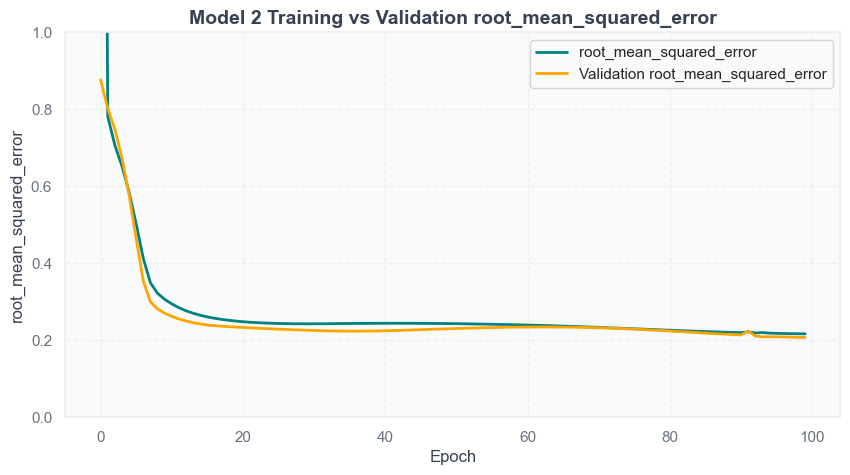

In [134]:
plt.figure(figsize=(10,5))
plt.plot(history2.history['root_mean_squared_error'], label='root_mean_squared_error', color='teal', linewidth=2)
plt.plot(history2.history['val_root_mean_squared_error'], label='Validation root_mean_squared_error', color='orange', linewidth=2)
plt.title('Model 2 Training vs Validation root_mean_squared_error', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('root_mean_squared_error')
plt.ylim(0, 1.0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [135]:
train_loss_model2 = min(history2.history['loss'])
val_loss_model2 = min(history2.history['val_loss'])

print('best train loss model 2:', train_loss_model2)
print('best val loss model 2:', val_loss_model2)

best train loss model 2: 0.046918876469135284
best val loss model 2: 0.04293697699904442


In [136]:
avg_train_loss_model2 = np.mean(history2.history['loss'])
avg_val_loss_model2 = np.mean(history2.history['val_loss'])
print(f"Average Training Loss: {avg_train_loss_model2:.4f}")
print(f"Average Validation Loss: {avg_val_loss_model2:.4f}")

Average Training Loss: 0.2421
Average Validation Loss: 0.0802


Pada model kedua ini, saya mencoba untuk menggunakan tetap 3 Hidden layer namun menggunakan fungsi aktivasi yang berbeda, yaitu Hybrid antara 'Sigmoid' dan 'ReLU'. Activation sigmoid sendiri merupakan sebuah fungsi aktivasi di neural network yang map input value menjadi output antara 0-1.  
<br> 
Saya menggunakan sigmoid sebagai pederam noise pada layer awal Karena Sigmoid memetakan input ke rentang (0, 1), ia secara alami menormalisasi sinyal yang lewat. Hal ini mencegah outlier (seperti harga mobil yang terlalu murah atau KM yang terlalu tinggi) merusak kestabilan model di awal proses belajar. Setelah sinyal distabilkan oleh Sigmoid, ReLU memberikan ketajaman prediktif. ReLU sangat responsif terhadap perubahan data, sehingga ia mampu menangkap detail-detail kecil yang menentukan sisa 5-10% akurasi ($R^2$) yang biasanya sulit dikejar oleh fungsi aktivasi yang terlalu halus.
<br><br>
Dari graph diatas, model nampak cepat belajar. Dari epoch awal loss langsun turun tajam kebawah lalu tampil stagnan dan stabil tanpa ada volatile di 0.1. Menunjukkan bahwa model ini stabil daripada model sebelumnya dan menghasilkan nilai R2 0.94 dengan MAE 1601 USD. 

In [137]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

#### **D.1 Model 1 (Base Model) Evaluation**

In [138]:
y_pred__model1_log = model_1.predict(X_test)
y_pred_model1 = np.expm1(y_pred__model1_log)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


Text(0.5, 1.0, 'Model 1 Regression')

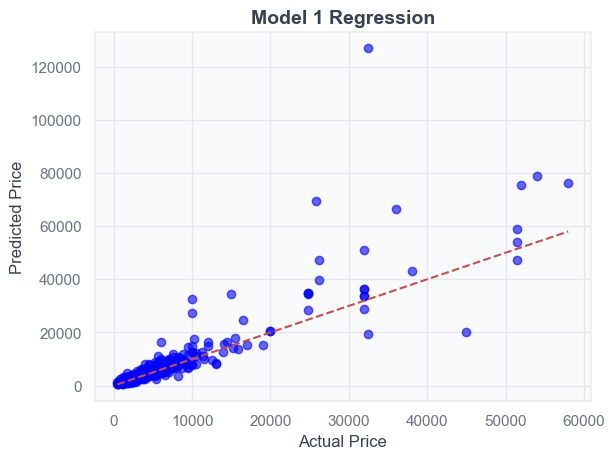

In [139]:
plt.scatter(y_test, y_pred_model1, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Model 1 Regression')

In [140]:
r2_model1 = r2_score(y_test, y_pred_model1)
rmse_model1 = root_mean_squared_error(y_test, y_pred_model1)
mae_model1 = mean_absolute_error(y_test, y_pred_model1)
mape_model1 = mean_absolute_percentage_error(y_test, y_pred_model1)
print('r2 score: ', r2_model1)
print('rmse score: ', rmse_model1)
print('mae score: ', mae_model1)
print('mape score: ', mape_model1)

r2 score:  0.3972400658609807
rmse score:  6638.695777839169
mae score:  2090.2152919555665
mape score:  0.27411017080960837


In [141]:
pd.DataFrame(list(zip(y_test,y_pred_model1)), columns = ['Actual Prices', 'Predicted Prices'])

,Actual Prices,Predicted Prices
0,5700.00,[5573.9814]
1,8000.00,[8682.795]
2,4849.99,[5386.2285]
3,10000.00,[7946.4775]
4,4000.00,[3558.9326]
...,...,...
395,36000.00,[66487.55]
396,1750.00,[2075.8042]
397,7500.00,[7503.691]
398,9100.00,[8137.337]


Setelah melakukan training, selanjutnya adalah kita mencoba untuk test model dengan data test yang sebelumnya belum pernah dilihat oleh model selama training. Ketika model diuji dengan data test, model menunjukkan hasil yang kurang baik dimana R2 berada pada nilai 0.39. Ini artinya model dapat memprediksi sebagian besar dengan baik tetapi memiliki isu overfit pada beberapa pola data. MAE yang didapatkan juga cukup mirip yaitu 2090 USD, yang artinya ketika kita predict sebuah price, maka prediksi kita meleset +/- 2090 USD. Contoh prediksi dapat dilihat pada tabel diatas, contohnya seperti actual prices adalah 5700 kemudian di prediksi 5573. Dari graph Actual Price dan Predicted Price, kita dapat melihat bahwa hasil prediksi sangat mendekati garis regression sebenarnya.

#### **D.2 Model 2 (Hybrid) Evaluation**

In [142]:
y_pred__model2_log = model_2.predict(X_test)
y_pred_model2 = np.expm1(y_pred__model2_log)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


Text(0.5, 1.0, 'Model 2 Regression')

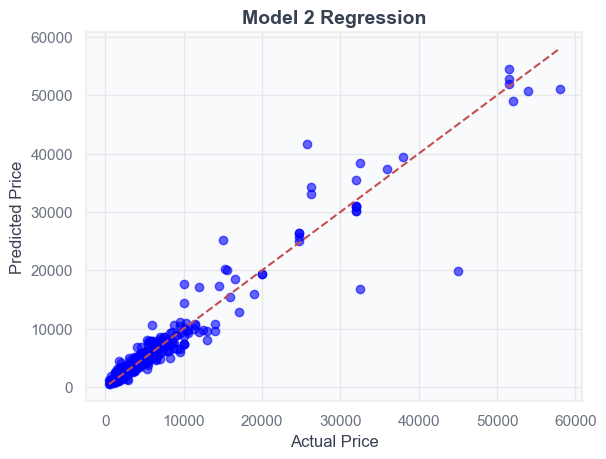

In [143]:
plt.scatter(y_test, y_pred_model2, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Model 2 Regression')

In [144]:
r2_model2 = r2_score(y_test, y_pred_model2)
rmse_model2 = root_mean_squared_error(y_test, y_pred_model2)
mape_model2 = mean_absolute_percentage_error(y_test, y_pred_model2)
mae_model2 = mean_absolute_error(y_test, y_pred_model2)
print('r2 score: ', r2_model2)
print('rmse score: ', rmse_model2)
print('mae score: ', mae_model2)
print('mape score: ', mape_model2)

r2 score:  0.9288884739286303
rmse score:  2280.240097271466
mae score:  1083.1002197479247
mape score:  0.20314777410360413


In [145]:
pd.DataFrame(list(zip(y_test,y_pred_model2)), columns = ['Actual Prices', 'Predicted Prices'])

,Actual Prices,Predicted Prices
0,5700.00,[5310.4116]
1,8000.00,[7944.591]
2,4849.99,[5637.923]
3,10000.00,[8807.137]
4,4000.00,[3758.4072]
...,...,...
395,36000.00,[37328.61]
396,1750.00,[2193.7332]
397,7500.00,[7768.722]
398,9100.00,[8881.937]


Pada model kedua yang menggunakan hybrid activation function, model mendapatkan sedikit peningkatan pada R2, yaitu model kedua mendapatkan R2 0.928. Nilai ini berarti model dapat menjelaskan sebagian besar variabilitas dari data. Dengan skor R2 0.928, ini menandakan performa model sudah sangat baik untuk memprediksi harga used car price dengan dataset yang ada. Selain itu, saya juga menganalisa satu perbedaan pada model kedua ini, yaitu bahwa model kedua lebih berani untuk menebak harga tinggi dibandingkan model pertama. Dan mendapatkan MAE yang sedikit lebih rendah dari model pertama, model kedua berhasil untuk achieve RMSE yang lebih rendah.

#### **D.4 Comparison**

In [146]:
result = {
    'Model': ['Model 1 (ReLU)', 'Model 2 (Hybrid)'],
    'R2 Score': [r2_model1, r2_model2],
    'RMSE Score': [rmse_model1, rmse_model2],
    'MAE Score': [mae_model1, mae_model2],
    'MAPE Score': [mape_model1, mape_model2]
}

# Membuat DataFrame
df_res = pd.DataFrame(result)

df_styled = df_res.set_index('Model').style.format({
    'R2 Score': '{:.4f}',
    'RMSE Score': '{:,.2f}',
    'MAE Score': '{:,.2f}',
    'MAPE Score': '{:.4%}'
}).set_caption("Comparison of Model Performance Metrics")

df_styled

,R2 Score,RMSE Score,MAE Score,MAPE Score
Model,,,,
Model 1 (ReLU),0.3972,"6,638.70","2,090.22",27.4110%
Model 2 (Hybrid),0.9289,"2,280.24","1,083.10",20.3148%


#### **D.5 Conclusion**

Dari kedua model yang telah saya training untuk menyelesaikan task regresi used car price ini, didapatkan bahwa model 2 (Hybrid) yang diperoleh dari hybrid activation function memberikan hasil yang terbaik di seluruh metrik utama yang digunakan. Peningkatan ini menunjukkan bahwa activation function yang dipilih memiliki dampak besar terhadap performa model.
<br> <br>
Findings:
- Model 1 cukup baik, namun ternyata memiliki indikasi overfit.  
- Model 2 memberikan peningkatan pada performa, hal ini diakibatkan karena penggunaan fungsi ReLU dan Sigmoid sebagai activation function. SIgmoin sebagai peredam noise dan ReLU dapat memperbaiki vanishing gradient problem. ketika kita lihat dari metricsnya, dibandingkan dengan model 1, MAE dan MAPE pada model 2 lebih dengan model 1.

Rekomendasi:
- Untuk meningkatkan performa model dan mencegah overfitting, dapat ditambahkan layer dropout ke dalam model
- Dataset dapat ditambah agar model dapat belajar data yang lebih bervariasi
- Mungkin dapat menambah layer untuk menangkap pola/pattern yang lebih kompleks